In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import random
import joblib
from datetime import datetime
from numba import cuda
from matplotlib import pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.metrics import mean_squared_error,r2_score,accuracy_score,confusion_matrix,classification_report
from imblearn.over_sampling import SMOTE,RandomOverSampler,ADASYN
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import RobustScaler,StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split,cross_validate,GridSearchCV,validation_curve,StratifiedKFold
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
import warnings

In [20]:
pd.set_option("display.max_columns",None)
pd.set_option("display.width",600)
pd.set_option("display.max_rows",600)
pd.set_option("display.float_format",lambda x:"%.3f" %x)
warnings.filterwarnings("ignore")

In [21]:
df = pd.read_csv('MetroPT3(AirCompressor).csv')
df.head()

,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.042,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000


In [22]:
df.tail()

,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
1516943,15169430,2020-09-01 03:59:10,-0.014,8.918,8.906,-0.022,8.918,59.675,0.042,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000
1516944,15169440,2020-09-01 03:59:20,-0.014,8.904,8.888,-0.020,8.904,59.600,0.045,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000
1516945,15169450,2020-09-01 03:59:30,-0.014,8.890,8.876,-0.022,8.892,59.600,0.042,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000
1516946,15169460,2020-09-01 03:59:40,-0.012,8.876,8.864,-0.022,8.878,59.550,0.045,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000
1516947,15169470,2020-09-01 03:59:50,-0.014,8.860,8.848,-0.022,8.864,59.475,0.042,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000


In [4]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [5]:
df['Air_Leak_Failure'] = 0

down_periods = [
    ('2020-04-18 00:00:00', '2020-04-18 23:59:00'),
    ('2020-05-29 23:30:00', '2020-05-30 06:00:00'),
    ('2020-06-05 10:00:00', '2020-06-07 14:30:00'),
    ('2020-07-15 14:30:00', '2020-07-15 19:00:00')
]

for start, end in down_periods:
    df.loc[(df['timestamp'] >= start) & (df['timestamp'] <= end), 'Air_Leak_Failure'] = 1

In [8]:
df[df["Caudal_impulses"] == 0]

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,Air_Leak_Failure
819115,2020-05-27 04:00:16,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
819120,2020-05-27 04:01:16,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
819125,2020-05-27 04:02:16,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
819130,2020-05-27 04:03:17,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
819135,2020-05-27 04:04:17,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
825969,2020-05-28 03:11:37,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
825974,2020-05-28 03:12:38,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
825979,2020-05-28 03:13:38,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
825984,2020-05-28 03:14:39,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0


In [9]:
df = df[(df["timestamp"] >= '2020-05-27 04:00:01') & ((df["timestamp"] < '2020-06-05 10:00:00'))]
df = df.iloc[0:50000]
len(df)

50000

In [17]:
df[df["Air_Leak_Failure"] == 0]

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,Air_Leak_Failure
819114,2020-05-27 04:00:04,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000,0
819115,2020-05-27 04:00:16,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
819116,2020-05-27 04:00:28,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000,0
819117,2020-05-27 04:00:40,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000,0
819118,2020-05-27 04:00:52,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869109,2020-06-02 19:13:36,-0.010,7.536,-0.008,-0.016,7.538,59.525,0.022,0.000,1.000,0.000,0.000,0.000,1.000,1.000,1.000,0
869110,2020-06-02 19:13:46,-0.012,7.526,-0.010,-0.016,7.528,59.625,0.022,0.000,1.000,0.000,0.000,0.000,1.000,1.000,1.000,0
869111,2020-06-02 19:13:56,-0.010,7.518,-0.008,-0.016,7.520,59.575,0.022,0.000,1.000,0.000,0.000,0.000,1.000,1.000,1.000,0
869112,2020-06-02 19:14:06,-0.010,7.508,-0.008,-0.018,7.508,59.400,0.022,0.000,1.000,0.000,0.000,0.000,1.000,1.000,1.000,0


In [18]:
df[df["Air_Leak_Failure"] == 0]

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,Air_Leak_Failure
819114,2020-05-27 04:00:04,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000,0
819115,2020-05-27 04:00:16,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
819116,2020-05-27 04:00:28,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000,0
819117,2020-05-27 04:00:40,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000,0
819118,2020-05-27 04:00:52,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869109,2020-06-02 19:13:36,-0.010,7.536,-0.008,-0.016,7.538,59.525,0.022,0.000,1.000,0.000,0.000,0.000,1.000,1.000,1.000,0
869110,2020-06-02 19:13:46,-0.012,7.526,-0.010,-0.016,7.528,59.625,0.022,0.000,1.000,0.000,0.000,0.000,1.000,1.000,1.000,0
869111,2020-06-02 19:13:56,-0.010,7.518,-0.008,-0.016,7.520,59.575,0.022,0.000,1.000,0.000,0.000,0.000,1.000,1.000,1.000,0
869112,2020-06-02 19:14:06,-0.010,7.508,-0.008,-0.018,7.508,59.400,0.022,0.000,1.000,0.000,0.000,0.000,1.000,1.000,1.000,0


In [16]:
tarih = datetime(2020,5,30,5,59,54)
tarih2 = datetime(2020,5,29,23,30,8)
fark = tarih - tarih2
fark = fark.seconds // 3600
fark

6

In [81]:
df.drop(index=df[df["timestamp"] > "2020-07-15 19:00:00"].index,inplace=True)

In [82]:
df.drop(index=df[(df["timestamp"] >= "2020-02-01 00:00:00") & ((df["timestamp"] < "2020-04-18 00:00:00"))].index,inplace=True)

In [83]:
len(df)

50000

In [84]:
df[df["Caudal_impulses"]==0]

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,Air_Leak_Failure
819115,2020-05-27 04:00:16,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
819120,2020-05-27 04:01:16,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
819125,2020-05-27 04:02:16,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
819130,2020-05-27 04:03:17,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
819135,2020-05-27 04:04:17,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
825969,2020-05-28 03:11:37,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
825974,2020-05-28 03:12:38,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
825979,2020-05-28 03:13:38,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
825984,2020-05-28 03:14:39,-0.010,8.168,8.158,-0.018,8.170,64.600,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0


In [85]:
len(df[df["Air_Leak_Failure"] == 0])

47640

In [10]:
df[df["Air_Leak_Failure"] == 1].index
df.loc[840740]

timestamp           2020-05-29 23:30:08
TP2                               8.236
TP3                               8.560
H1                               -0.012
DV_pressure                       1.956
Reservoirs                        8.560
Oil_temperature                  73.425
Motor_current                     5.575
COMP                              0.000
DV_eletric                        1.000
Towers                            1.000
MPG                               0.000
LPS                               0.000
Pressure_switch                   1.000
Oil_level                         1.000
Caudal_impulses                   1.000
Air_Leak_Failure                      1
Name: 840740, dtype: object

In [87]:
if((len(df[df["Air_Leak_Failure"] == 1]) + len(df[df["Air_Leak_Failure"] == 0])) == len(df)):
    print(True)

True


In [88]:
len(df[df["Air_Leak_Failure"] == 0]) / len(df) * 100

95.28

In [14]:
def df_summary(dataframe,head=10):
    print("##### SHAPE ######")
    print(df.shape)
    print("\n##### Degisken Turleri ######")
    print(df.dtypes)
    print("\n##### Eksik Degerler ######")
    print(df.isnull().sum())

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 48073 entries, 842737 to 890809
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         48073 non-null  object 
 1   TP2               48073 non-null  float64
 2   TP3               48073 non-null  float64
 3   H1                48073 non-null  float64
 4   DV_pressure       48073 non-null  float64
 5   Reservoirs        48073 non-null  float64
 6   Oil_temperature   48073 non-null  float64
 7   Motor_current     48073 non-null  float64
 8   COMP              48073 non-null  float64
 9   DV_eletric        48073 non-null  float64
 10  Towers            48073 non-null  float64
 11  MPG               48073 non-null  float64
 12  LPS               48073 non-null  float64
 13  Pressure_switch   48073 non-null  float64
 14  Oil_level         48073 non-null  float64
 15  Caudal_impulses   48073 non-null  float64
 16  Air_Leak_Failure  48073 non-null  

In [12]:
df["timestamp"] =  pd.to_datetime(df["timestamp"],format='%Y-%m-%d %H:%M:%S')

In [13]:
df["timestamp"].dtype

dtype('<M8[ns]')

In [18]:
df_summary(df)

##### SHAPE ######
(610151, 17)

##### Degisken Turleri ######
timestamp           datetime64[ns]
TP2                        float64
TP3                        float64
H1                         float64
DV_pressure                float64
Reservoirs                 float64
Oil_temperature            float64
Motor_current              float64
COMP                       float64
DV_eletric                 float64
Towers                     float64
MPG                        float64
LPS                        float64
Pressure_switch            float64
Oil_level                  float64
Caudal_impulses            float64
Air_Leak_Failure             int64
dtype: object

##### Eksik Degerler ######
timestamp           0
TP2                 0
TP3                 0
H1                  0
DV_pressure         0
Reservoirs          0
Oil_temperature     0
Motor_current       0
COMP                0
DV_eletric          0
Towers              0
MPG                 0
LPS                 0
Pressure_swit

In [19]:
for col in df.columns:
    print(f"{col} degiskeninin benzersiz deger sayisi : {df[col].nunique()}\n")

timestamp degiskeninin benzersiz deger sayisi : 610151

TP2 degiskeninin benzersiz deger sayisi : 4826

TP3 degiskeninin benzersiz deger sayisi : 3135

H1 degiskeninin benzersiz deger sayisi : 1866

DV_pressure degiskeninin benzersiz deger sayisi : 1748

Reservoirs degiskeninin benzersiz deger sayisi : 3152

Oil_temperature degiskeninin benzersiz deger sayisi : 2169

Motor_current degiskeninin benzersiz deger sayisi : 1495

COMP degiskeninin benzersiz deger sayisi : 2

DV_eletric degiskeninin benzersiz deger sayisi : 2

Towers degiskeninin benzersiz deger sayisi : 2

MPG degiskeninin benzersiz deger sayisi : 2

LPS degiskeninin benzersiz deger sayisi : 2

Pressure_switch degiskeninin benzersiz deger sayisi : 2

Oil_level degiskeninin benzersiz deger sayisi : 2

Caudal_impulses degiskeninin benzersiz deger sayisi : 2

Air_Leak_Failure degiskeninin benzersiz deger sayisi : 2



In [89]:
def degisken_turlerini_ayır(dataframe,cat_th=10,car_th=20):
    
    kategorik_degiskenler = [col for col in dataframe.columns if dataframe[col].dtype == 'O']
    sayisal_degiskenler = [col for col in dataframe.columns if dataframe[col].dtype != 'O']
    
    kat_ama_car = [col for col in dataframe.columns if dataframe[col].dtype == 'O' and dataframe[col].nunique() > car_th]
    say_ama_cat = [col for col in dataframe.columns if dataframe[col].dtype != 'O' and dataframe[col].nunique() < cat_th]
    
    kategorik_degiskenler = kategorik_degiskenler + say_ama_cat
    
    kategorik_degiskenler = [col for col in kategorik_degiskenler if col not in kat_ama_car]
    
    sayisal_degiskenler = [col for col in sayisal_degiskenler if col not in say_ama_cat]
    
    return kategorik_degiskenler,sayisal_degiskenler,kat_ama_car

In [15]:
kategorik_degiskenler,sayisal_degiskenler,kat_ama_car = degisken_turlerini_ayır(df)

In [16]:
kategorik_degiskenler

['COMP',
 'DV_eletric',
 'Towers',
 'MPG',
 'LPS',
 'Pressure_switch',
 'Oil_level',
 'Caudal_impulses',
 'Air_Leak_Failure']

In [17]:
sayisal_degiskenler

['TP2',
 'TP3',
 'H1',
 'DV_pressure',
 'Reservoirs',
 'Oil_temperature',
 'Motor_current']

In [18]:
kat_ama_car

['timestamp']

In [19]:
sayisal_degiskenler = [col for col in sayisal_degiskenler if col != 'timestamp']

In [20]:
sayisal_degiskenler

['TP2',
 'TP3',
 'H1',
 'DV_pressure',
 'Reservoirs',
 'Oil_temperature',
 'Motor_current']

In [27]:
df.head()

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,Air_Leak_Failure
562564,2020-04-18 00:00:01,-0.018,8.248,8.238,-0.024,8.248,49.450,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000,1
562565,2020-04-18 00:00:13,-0.018,8.248,8.238,-0.024,8.248,49.450,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000,1
562566,2020-04-18 00:00:24,-0.018,8.248,8.238,-0.024,8.248,49.450,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000,1
562567,2020-04-18 00:00:36,-0.018,8.248,8.238,-0.024,8.248,49.450,0.040,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1
562568,2020-04-18 00:00:49,-0.018,8.248,8.238,-0.024,8.248,49.450,0.040,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000,1


In [28]:
df[sayisal_degiskenler].describe().T

,count,mean,std,min,25%,50%,75%,max
TP2,610151.000,1.793,3.562,-0.032,-0.014,-0.012,-0.010,10.676
TP3,610151.000,8.940,0.672,0.892,8.440,8.898,9.474,10.288
H1,610151.000,7.091,3.719,-0.036,8.158,8.704,9.346,10.288
DV_pressure,610151.000,0.130,0.540,-0.030,-0.022,-0.020,-0.018,7.874
Reservoirs,610151.000,8.940,0.672,0.870,8.440,8.900,9.474,10.290
Oil_temperature,610151.000,64.064,6.355,19.825,59.875,64.600,68.250,89.050
Motor_current,610151.000,2.347,2.371,0.020,0.042,3.592,3.890,9.270


In [29]:
df.isnull().sum()

timestamp           0
TP2                 0
TP3                 0
H1                  0
DV_pressure         0
Reservoirs          0
Oil_temperature     0
Motor_current       0
COMP                0
DV_eletric          0
Towers              0
MPG                 0
LPS                 0
Pressure_switch     0
Oil_level           0
Caudal_impulses     0
Air_Leak_Failure    0
dtype: int64

In [30]:
def categorik_degisken_ozeti(dataframe,kategorik_degiskenler: list,plot = True):
    for col in kategorik_degiskenler:
            print(pd.DataFrame({col : dataframe[col].value_counts(),
                                "Veri Setindeki Yüzdelik Orani" : dataframe[col].value_counts() / len(dataframe[col]) * 100 }))
            if plot :
                plt.figure(figsize=(10,5))
                sns.countplot(data=dataframe,x=col)
                plt.show(block=True)

         COMP  Veri Setindeki Yüzdelik Orani
1.000  476097                         78.029
0.000  134054                         21.971


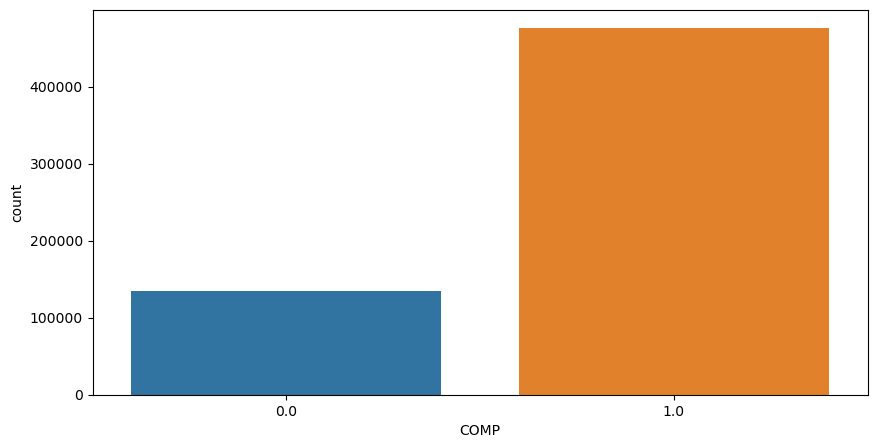

       DV_eletric  Veri Setindeki Yüzdelik Orani
0.000      479559                         78.597
1.000      130592                         21.403


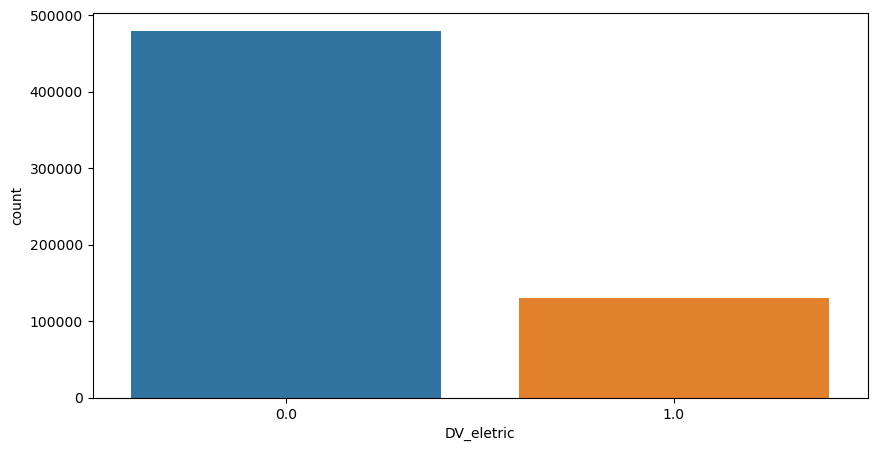

       Towers  Veri Setindeki Yüzdelik Orani
1.000  546255                         89.528
0.000   63896                         10.472


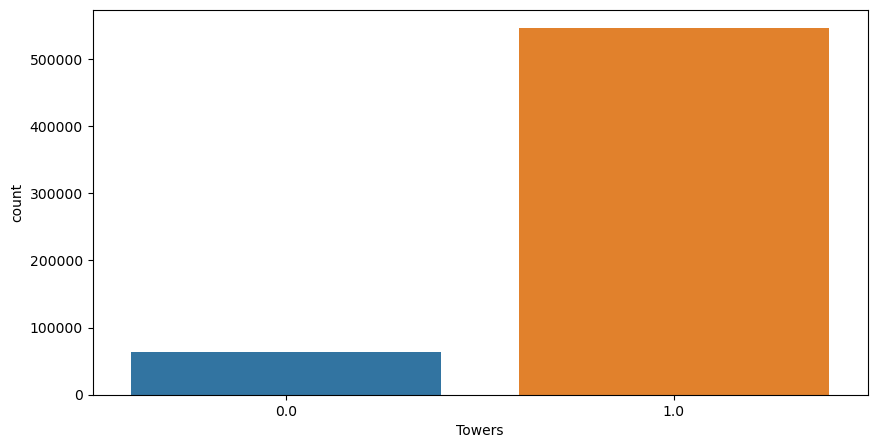

          MPG  Veri Setindeki Yüzdelik Orani
1.000  471206                         77.228
0.000  138945                         22.772


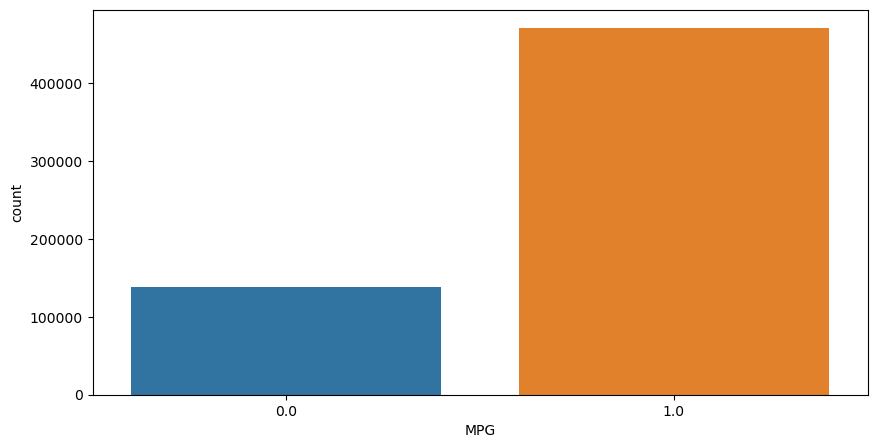

          LPS  Veri Setindeki Yüzdelik Orani
0.000  606979                         99.480
1.000    3172                          0.520


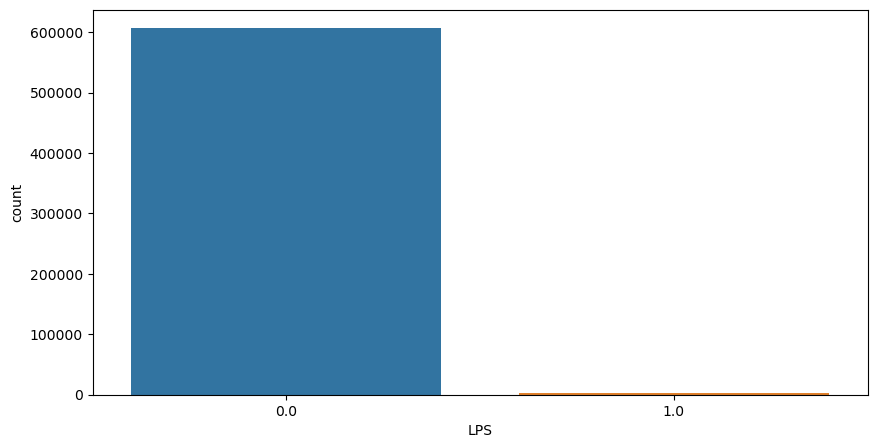

       Pressure_switch  Veri Setindeki Yüzdelik Orani
1.000           600765                         98.462
0.000             9386                          1.538


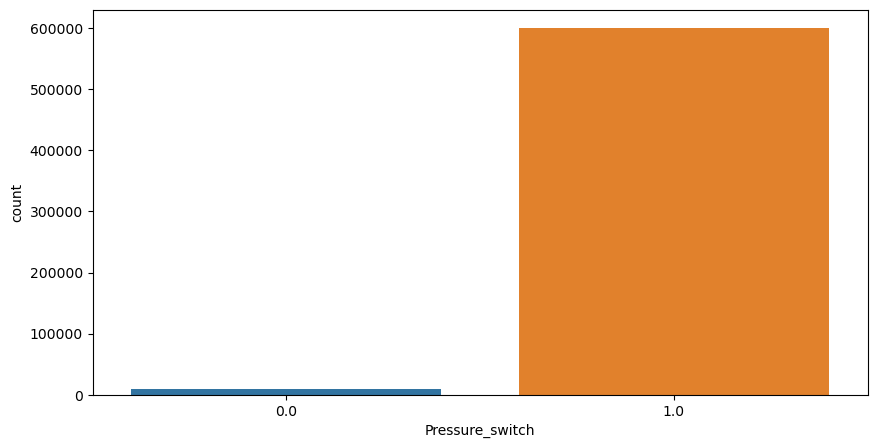

       Oil_level  Veri Setindeki Yüzdelik Orani
1.000     596904                         97.829
0.000      13247                          2.171


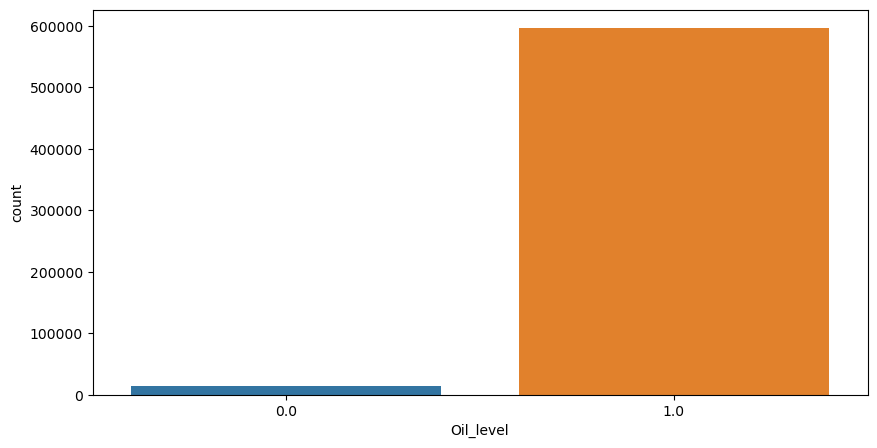

       Caudal_impulses  Veri Setindeki Yüzdelik Orani
1.000           596904                         97.829
0.000            13247                          2.171


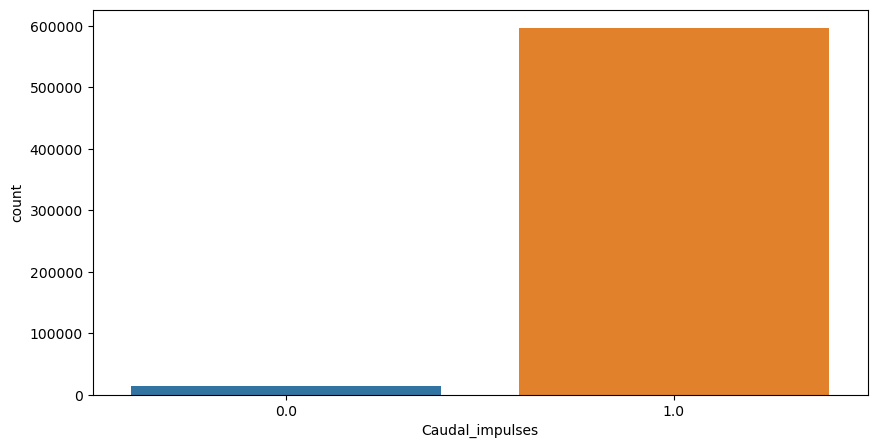

   Air_Leak_Failure  Veri Setindeki Yüzdelik Orani
0            580197                         95.091
1             29954                          4.909


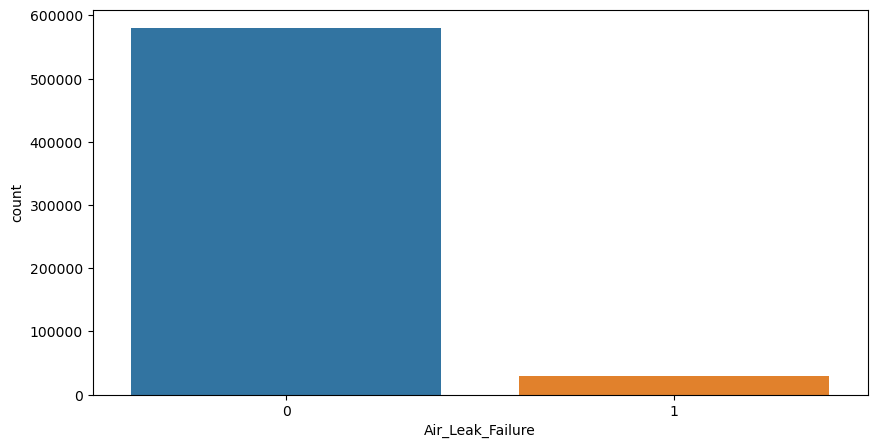

In [31]:
categorik_degisken_ozeti(df,kategorik_degiskenler)

In [32]:
sayisal_degiskenler = [col for col in sayisal_degiskenler if col not in ["TP2","DV_pressure"]]

In [39]:
def sayisal_degisken_ozeti(dataframe,sayisal_degiskenler,plot=True):
    for col in sayisal_degiskenler:
        print(pd.DataFrame({col : dataframe[col].describe().T}))
        
        if plot:
            plt.figure(figsize=(16,12))
            sns.histplot(data=dataframe,x=col,kde=True)
            plt.grid()
            plt.show(block=True)

             TP3
count 610151.000
mean       8.940
std        0.672
min        0.892
25%        8.440
50%        8.898
75%        9.474
max       10.288


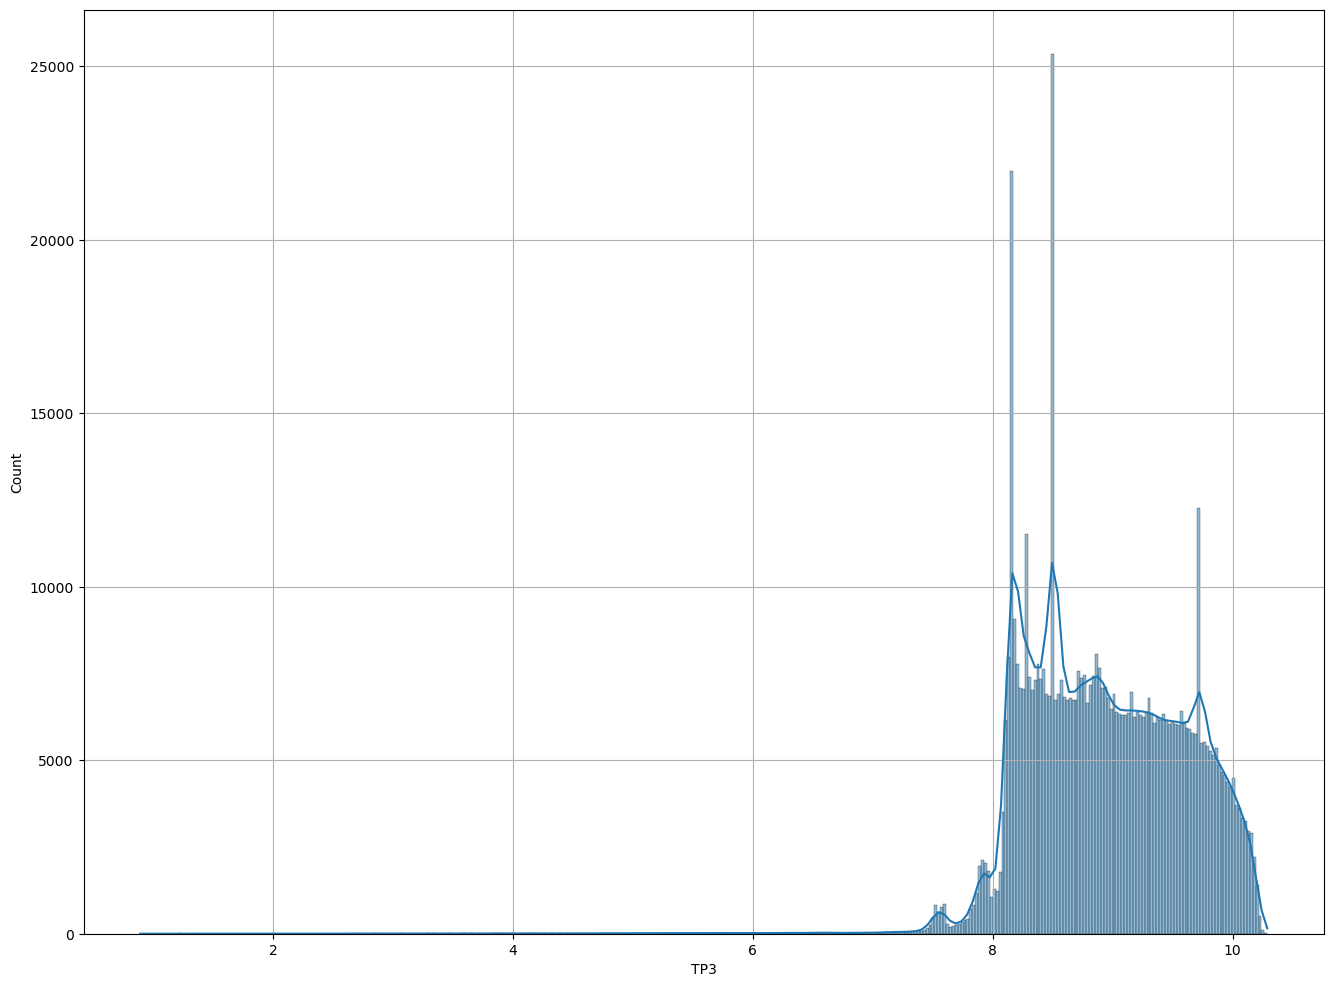

              H1
count 610151.000
mean       7.091
std        3.719
min       -0.036
25%        8.158
50%        8.704
75%        9.346
max       10.288


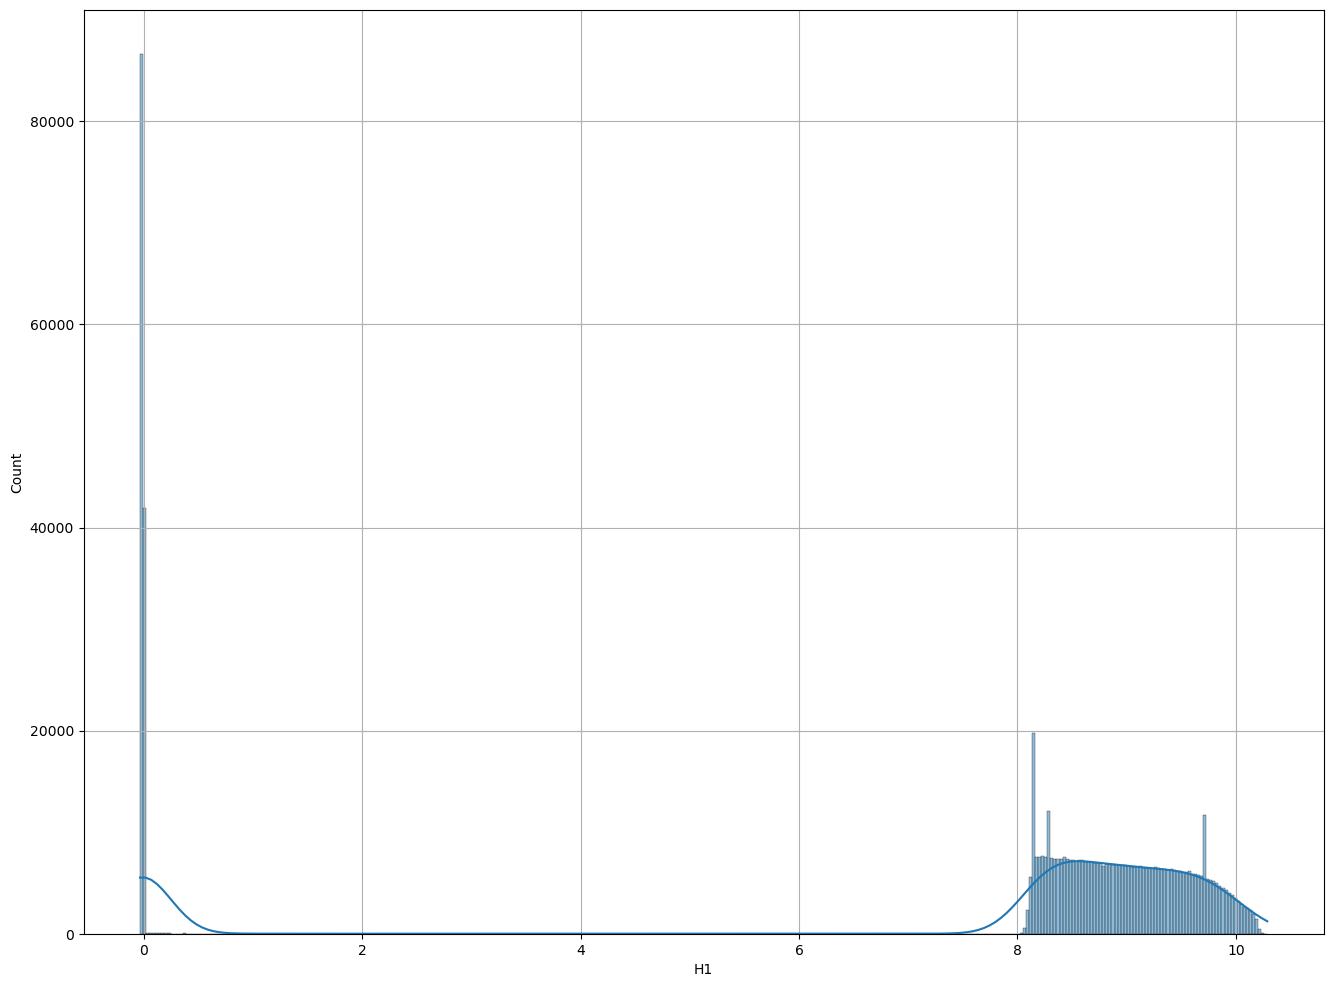

       Reservoirs
count  610151.000
mean        8.940
std         0.672
min         0.870
25%         8.440
50%         8.900
75%         9.474
max        10.290


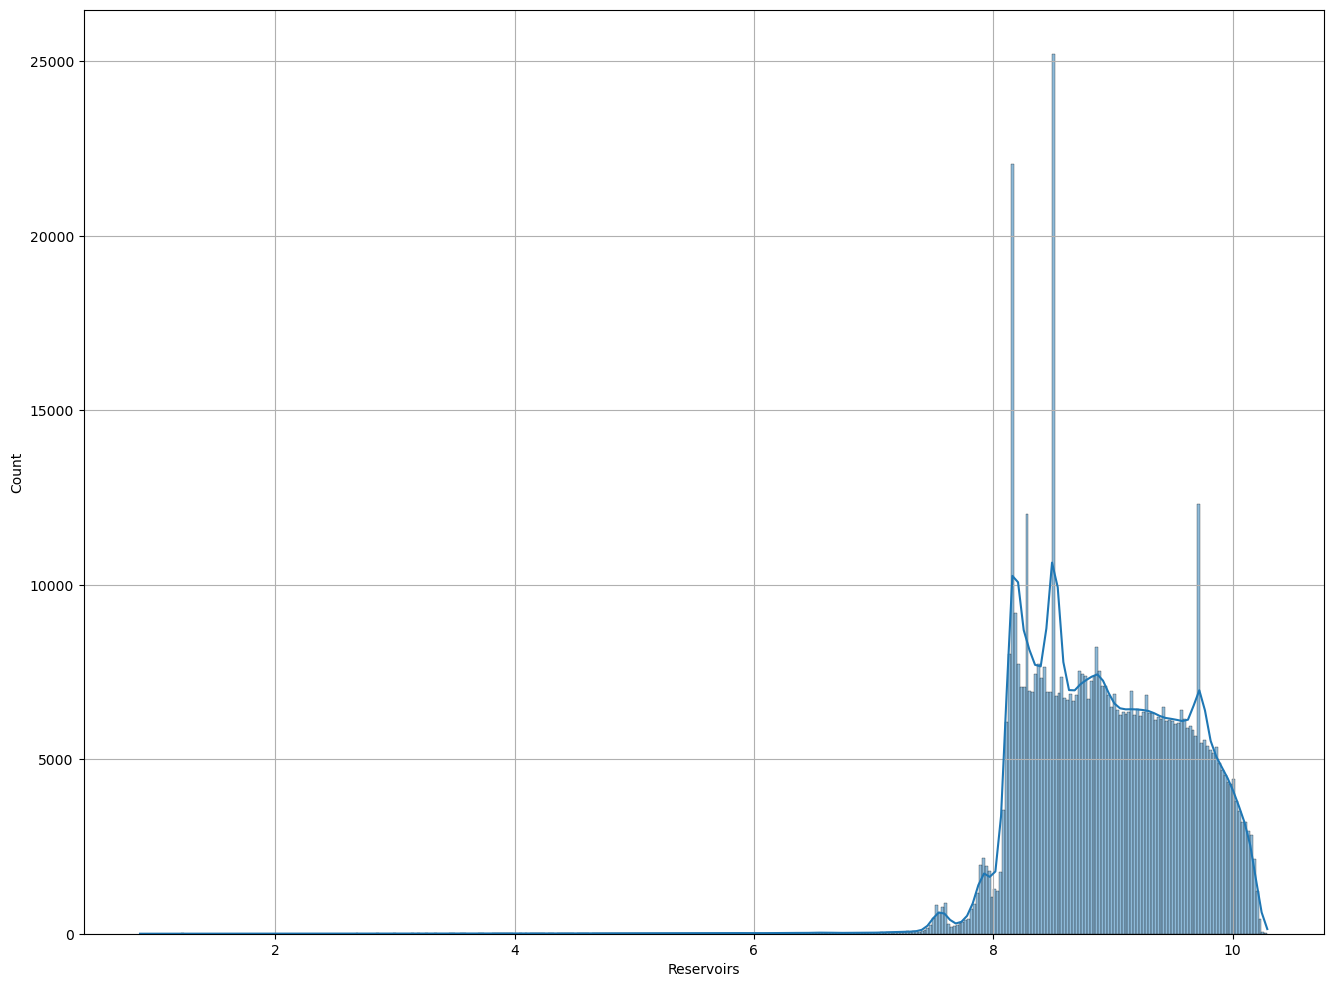

       Oil_temperature
count       610151.000
mean            64.064
std              6.355
min             19.825
25%             59.875
50%             64.600
75%             68.250
max             89.050


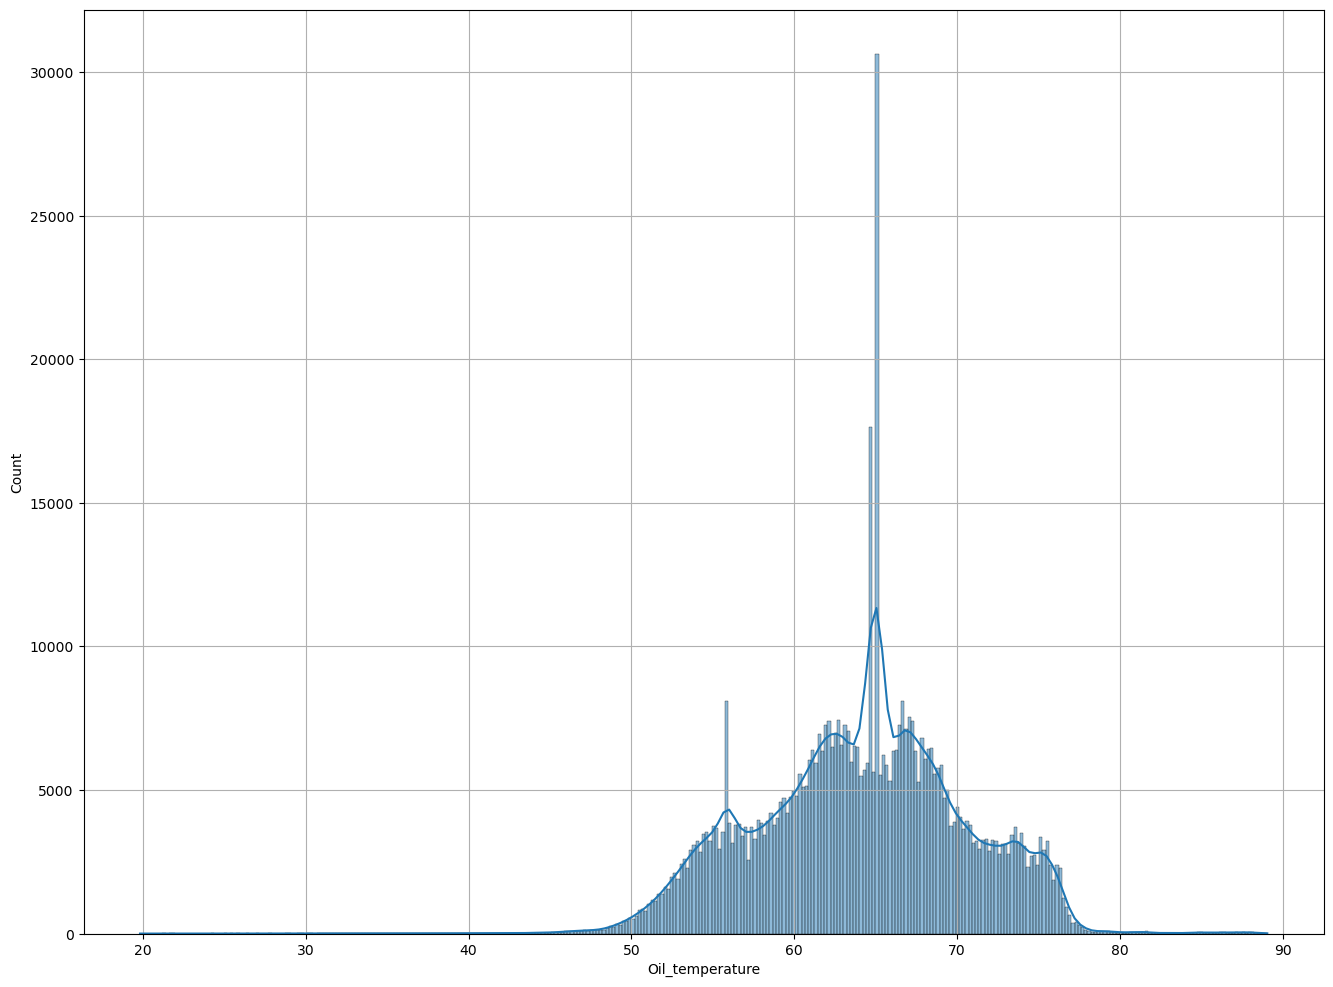

       Motor_current
count     610151.000
mean           2.347
std            2.371
min            0.020
25%            0.042
50%            3.592
75%            3.890
max            9.270


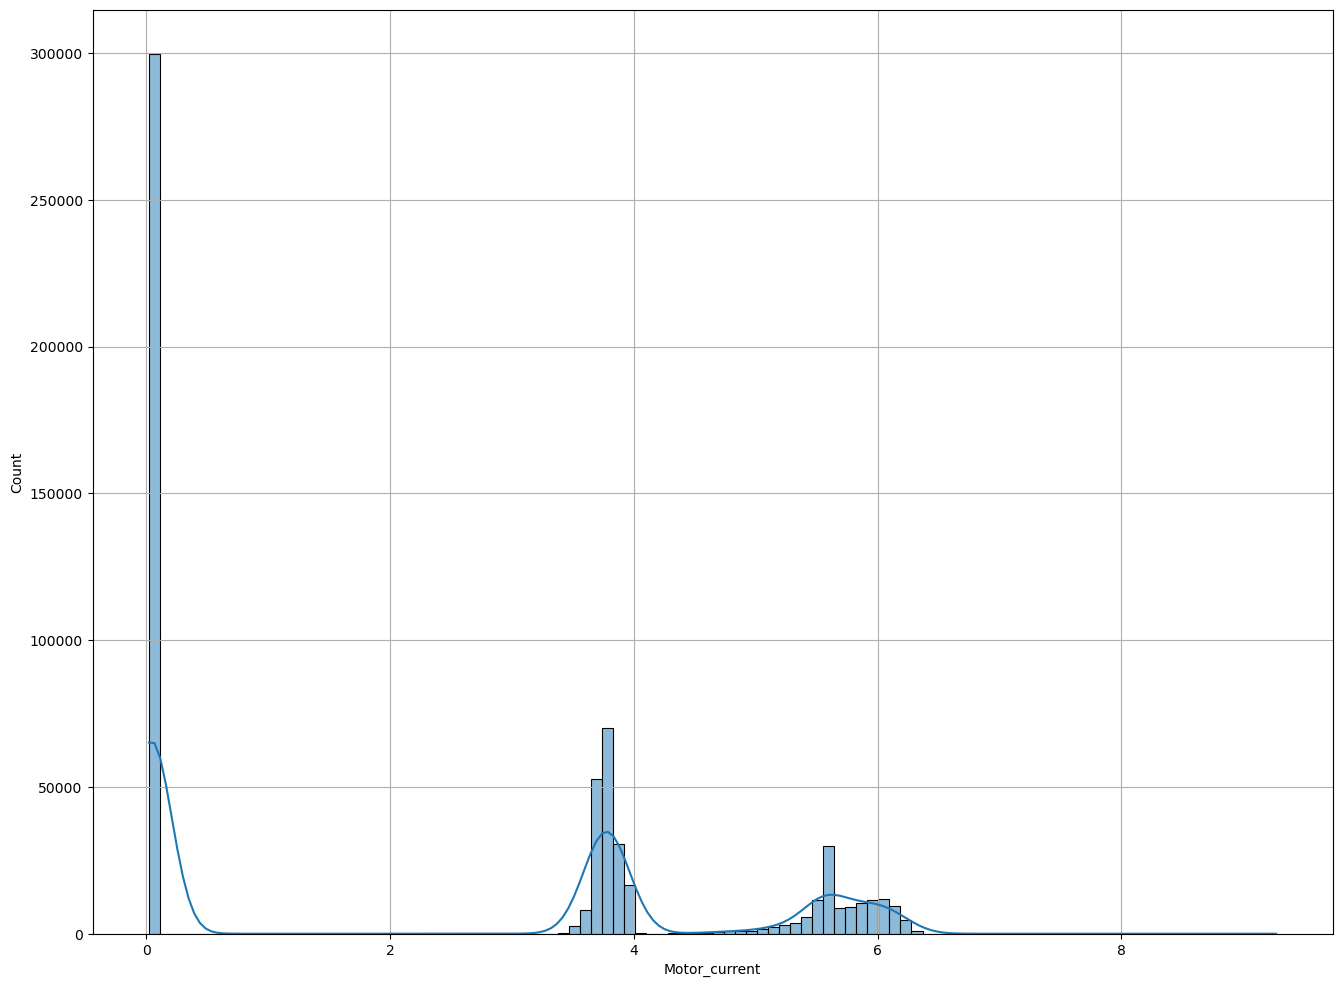

In [40]:
sayisal_degisken_ozeti(df,sayisal_degiskenler)

In [41]:
def sayisal_degisken_ozeti_with_hue(dataframe,sayisal_degiskenler,hue,plot=True):
    for col in sayisal_degiskenler:
        print(pd.DataFrame({col : dataframe[col].describe().T}))
        
        if plot:
            plt.figure(figsize=(16,12))
            sns.histplot(data=dataframe,x=col,hue=hue,kde=True)
            plt.grid()
            plt.show(block=True)

             TP3
count 610151.000
mean       8.940
std        0.672
min        0.892
25%        8.440
50%        8.898
75%        9.474
max       10.288


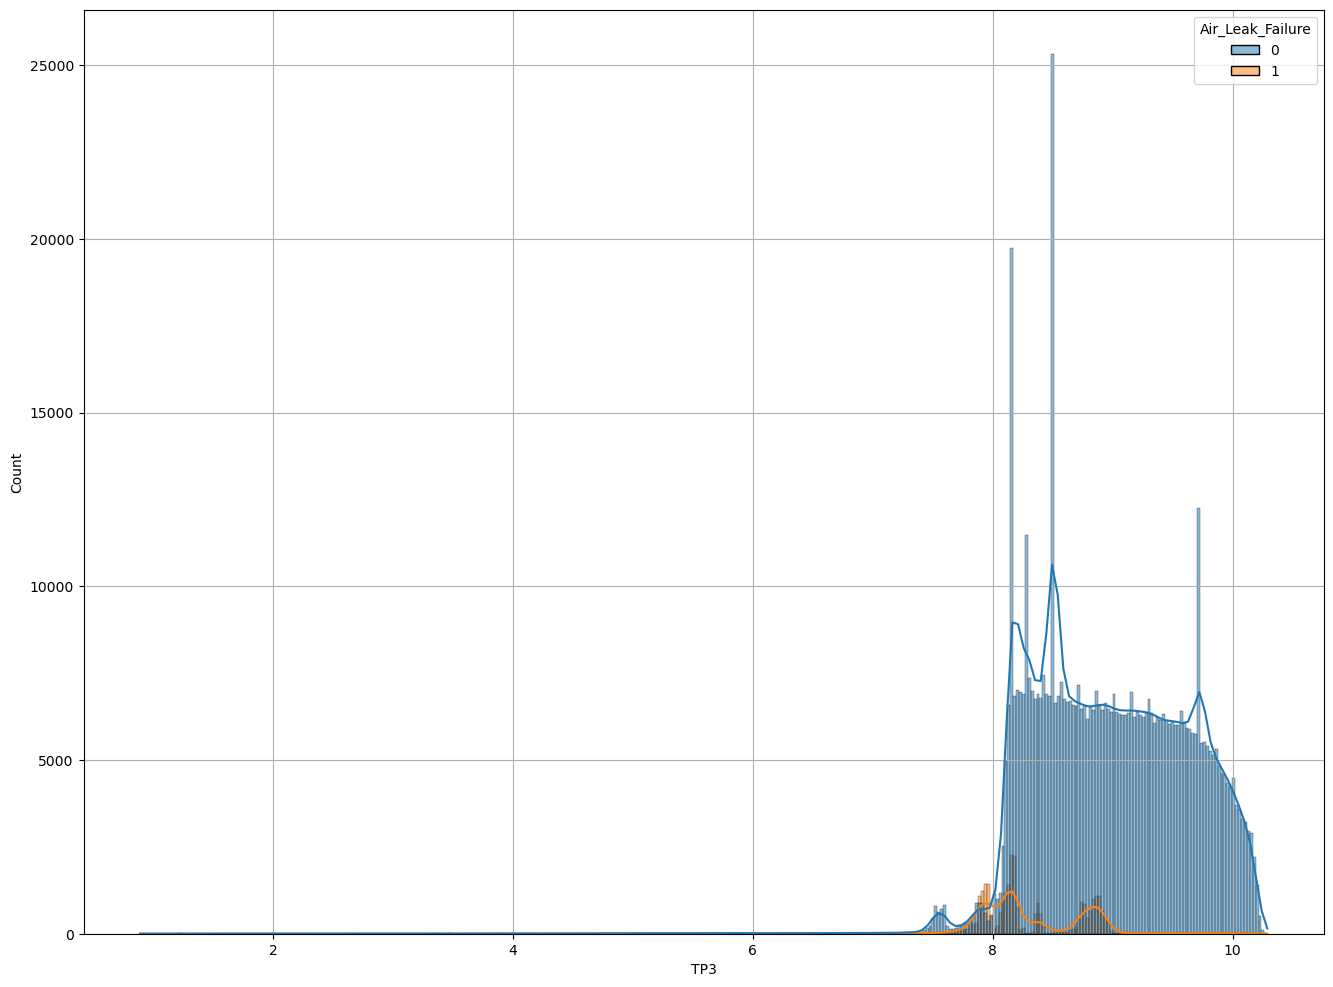

              H1
count 610151.000
mean       7.091
std        3.719
min       -0.036
25%        8.158
50%        8.704
75%        9.346
max       10.288


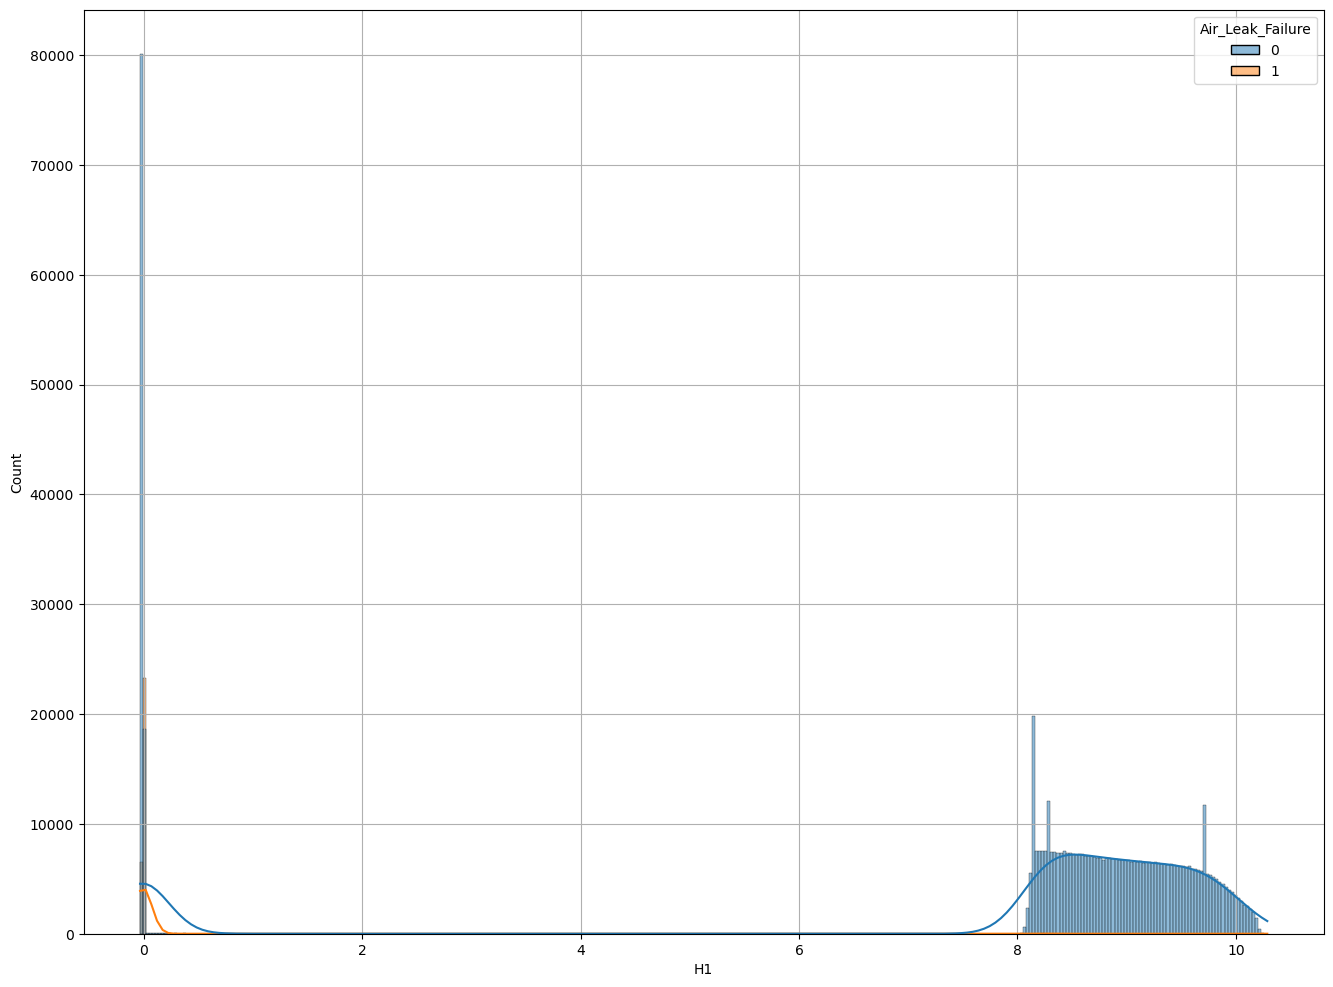

       Reservoirs
count  610151.000
mean        8.940
std         0.672
min         0.870
25%         8.440
50%         8.900
75%         9.474
max        10.290


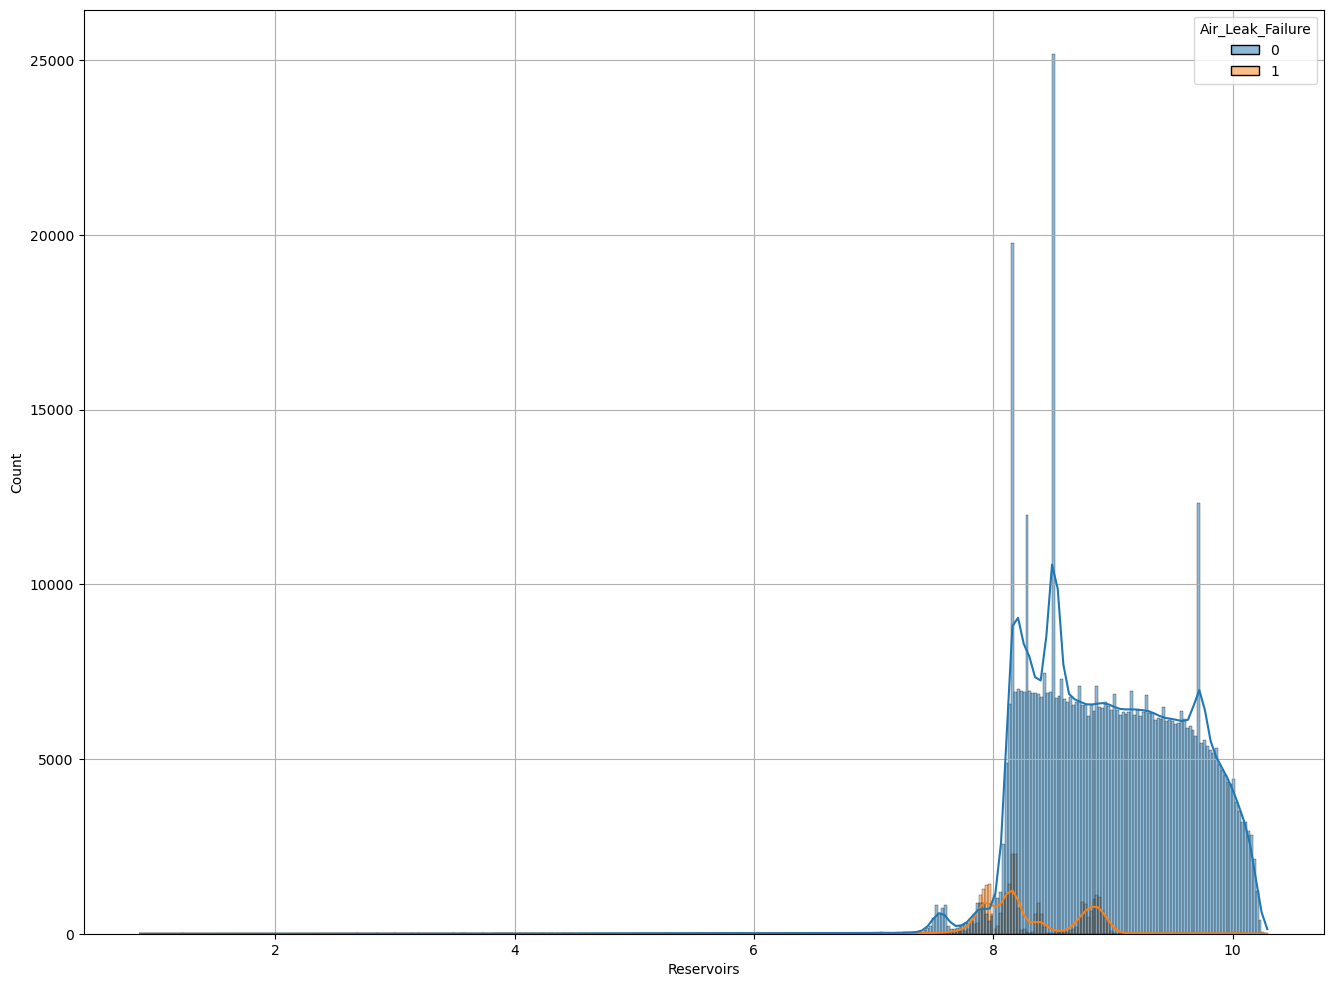

       Oil_temperature
count       610151.000
mean            64.064
std              6.355
min             19.825
25%             59.875
50%             64.600
75%             68.250
max             89.050


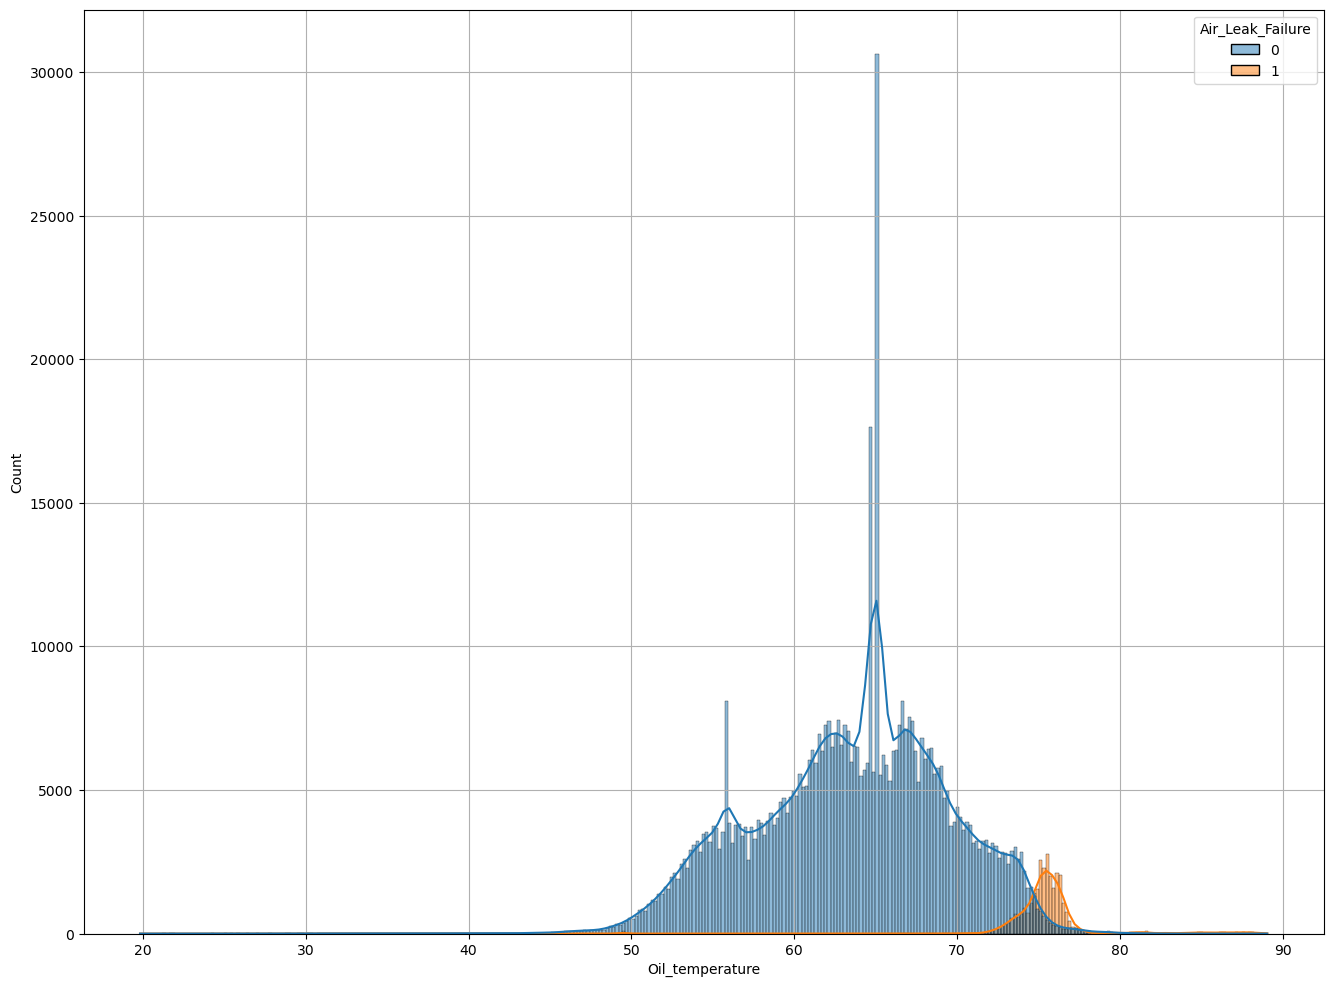

       Motor_current
count     610151.000
mean           2.347
std            2.371
min            0.020
25%            0.042
50%            3.592
75%            3.890
max            9.270


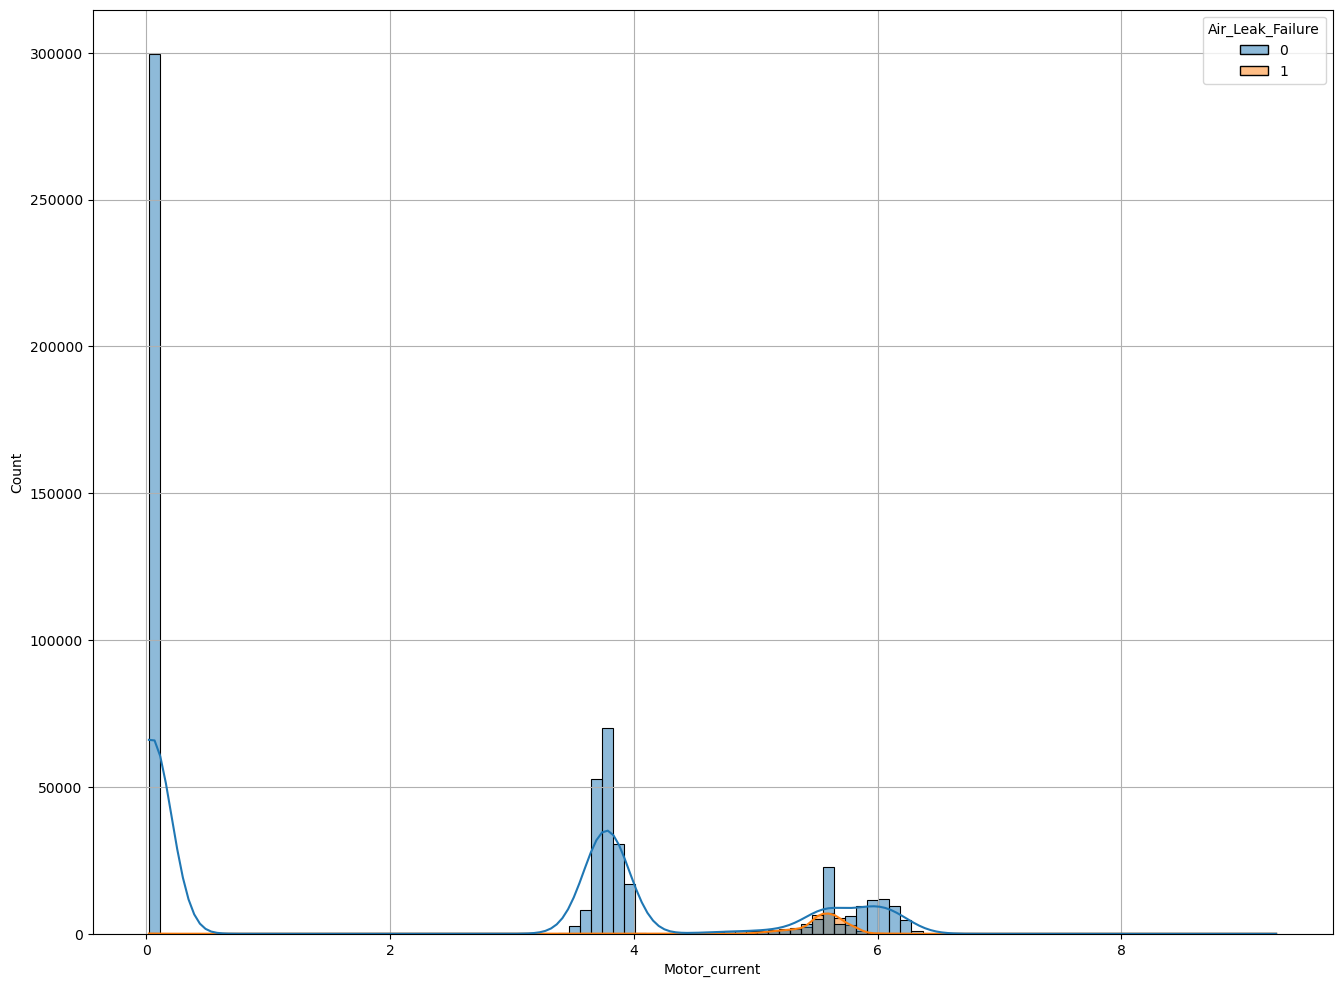

In [42]:
sayisal_degisken_ozeti_with_hue(df,sayisal_degiskenler,hue="Air_Leak_Failure")

In [63]:
def outlier_th(dataframe,col,q1=0.15,q3=0.85,plot=True):
    quar1 = dataframe[col].quantile(q1)
    quar3 = dataframe[col].quantile(q3)
    
    iqr = quar3 - quar1
    
    low_limit = quar1 - 1.5 * iqr
    up_limit = quar3 + 1.5 * iqr
    
    if plot:
        plt.figure(figsize=(16,8))
        sns.boxplot(data=dataframe,x=col,color="darkorange")
        plt.show(block=False)
    
    return low_limit,up_limit

In [21]:
kategorik_degiskenler,sayisal_degiskenler,kat_ama_car = degisken_turlerini_ayır(df)

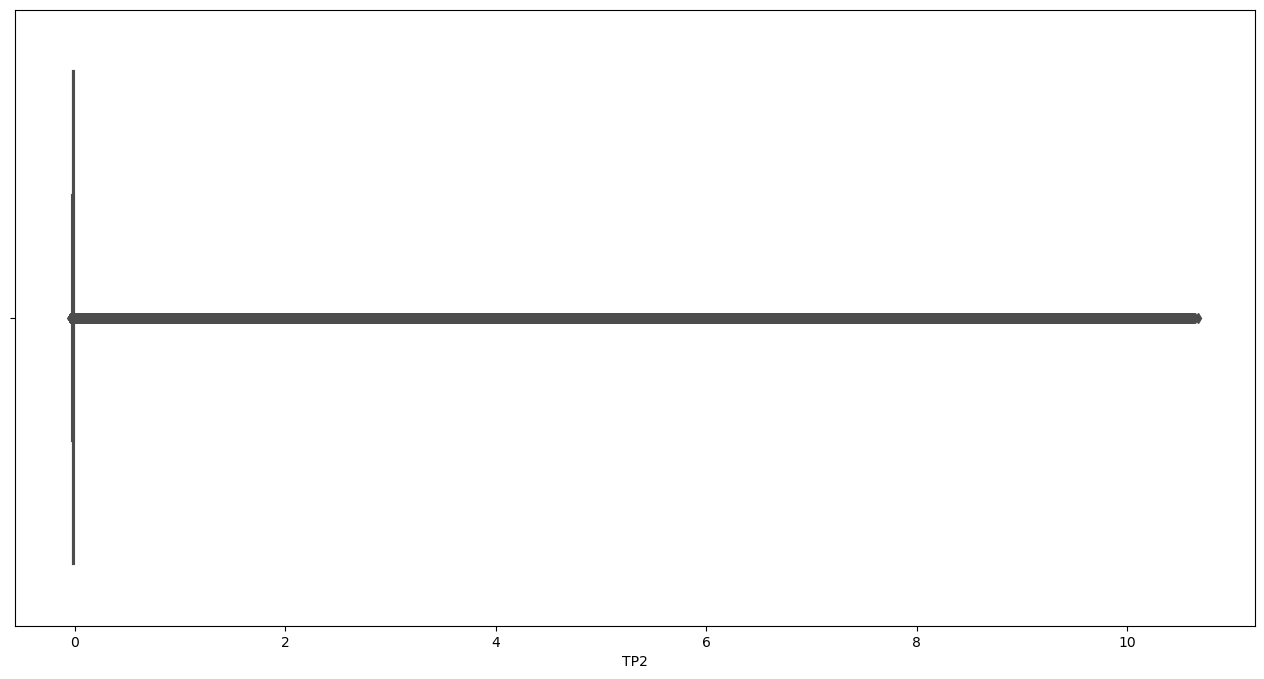

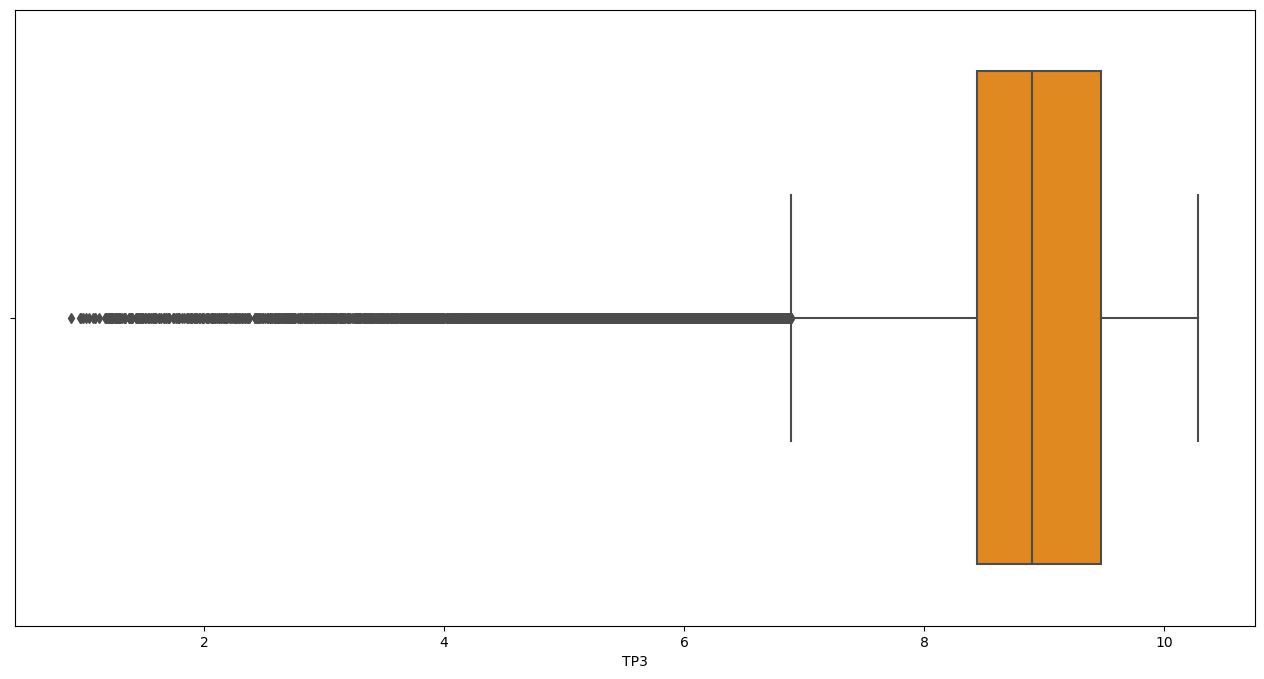

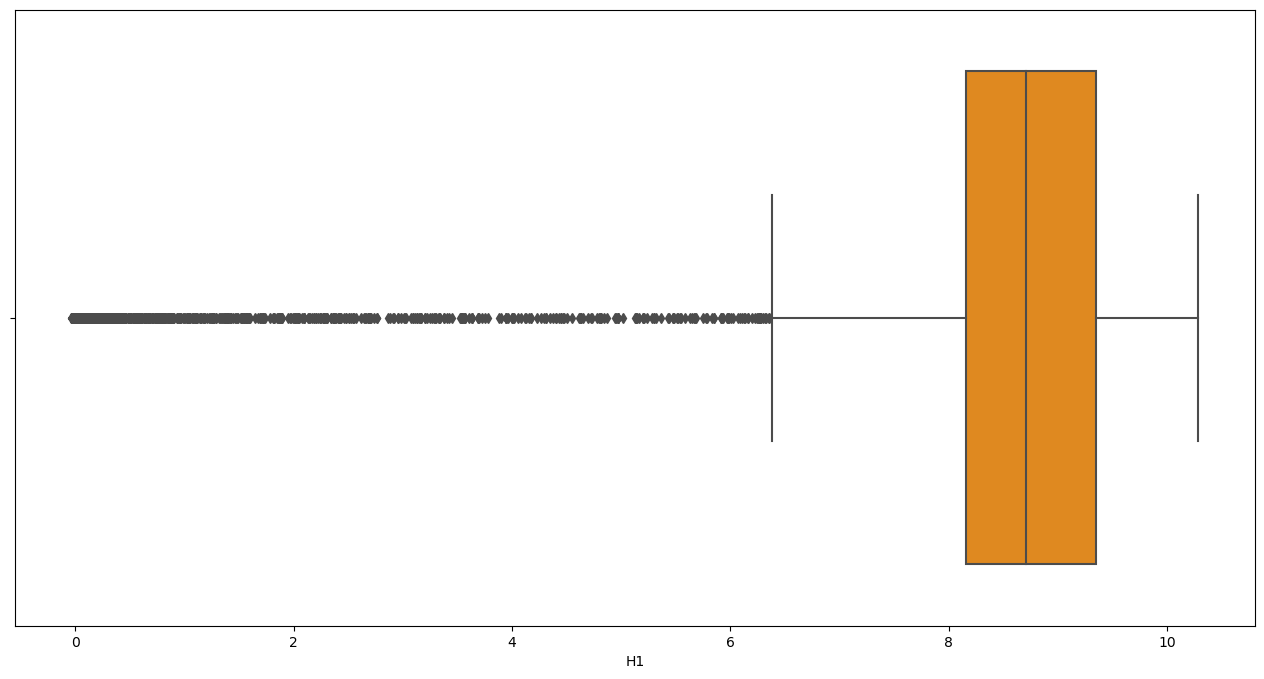

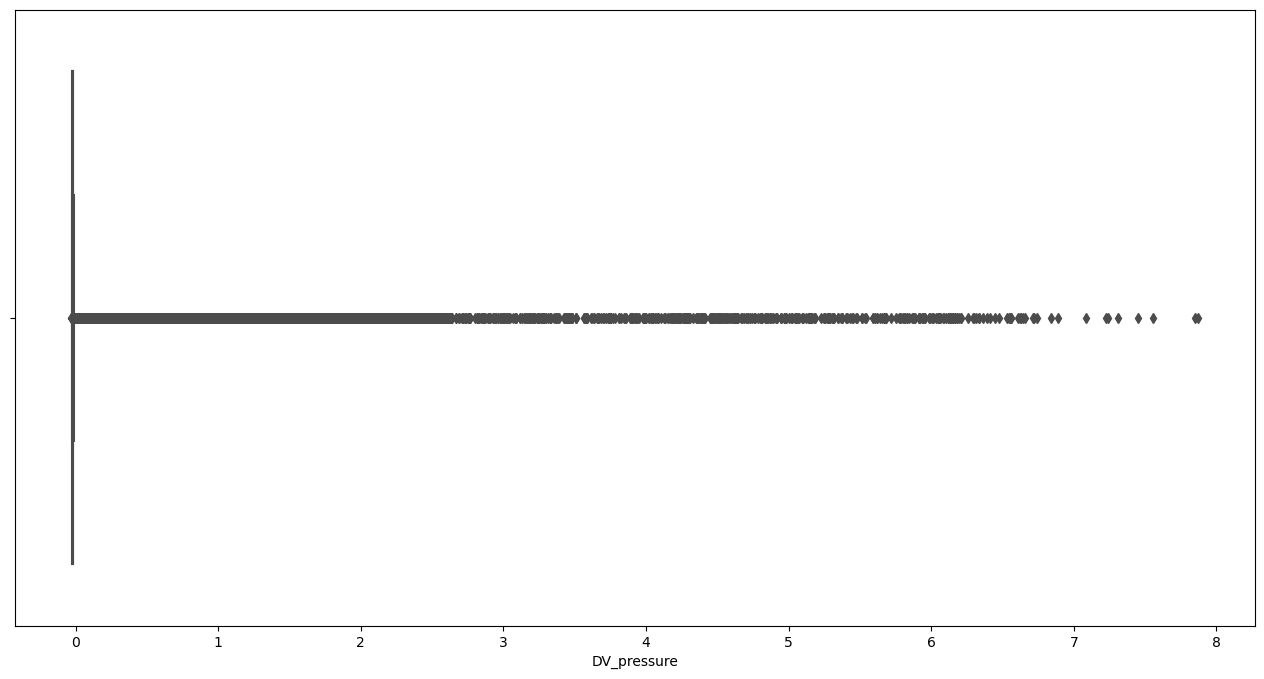

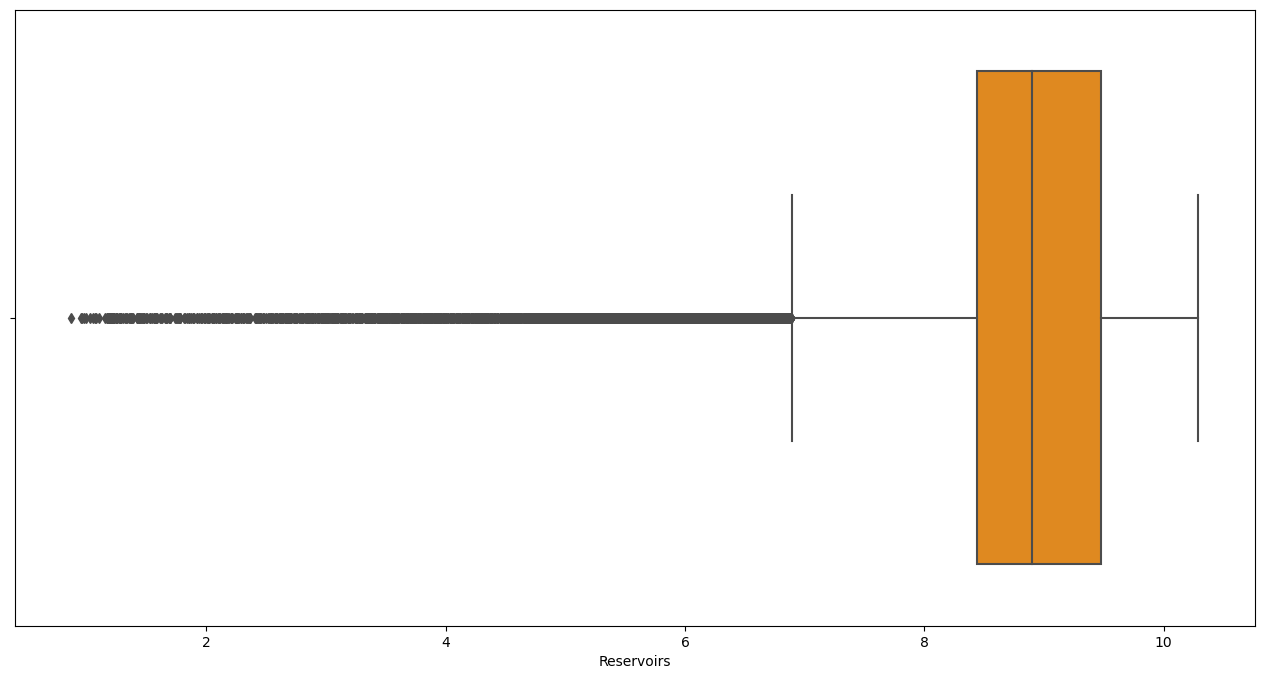

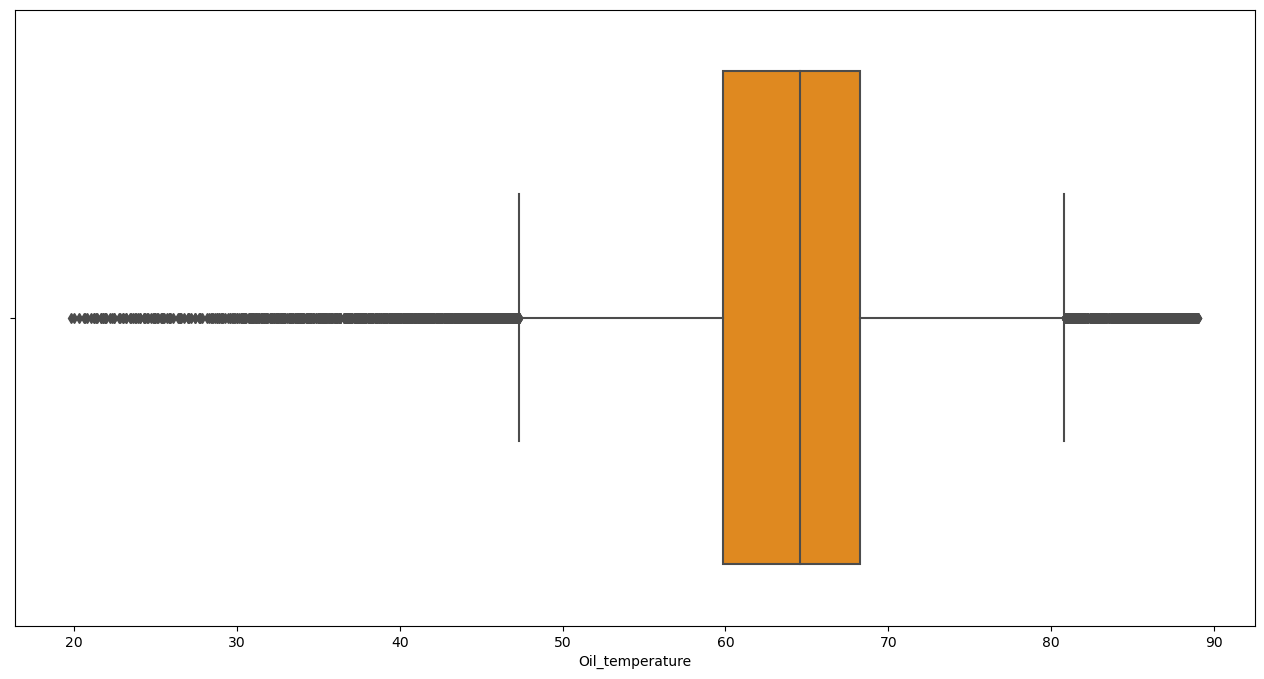

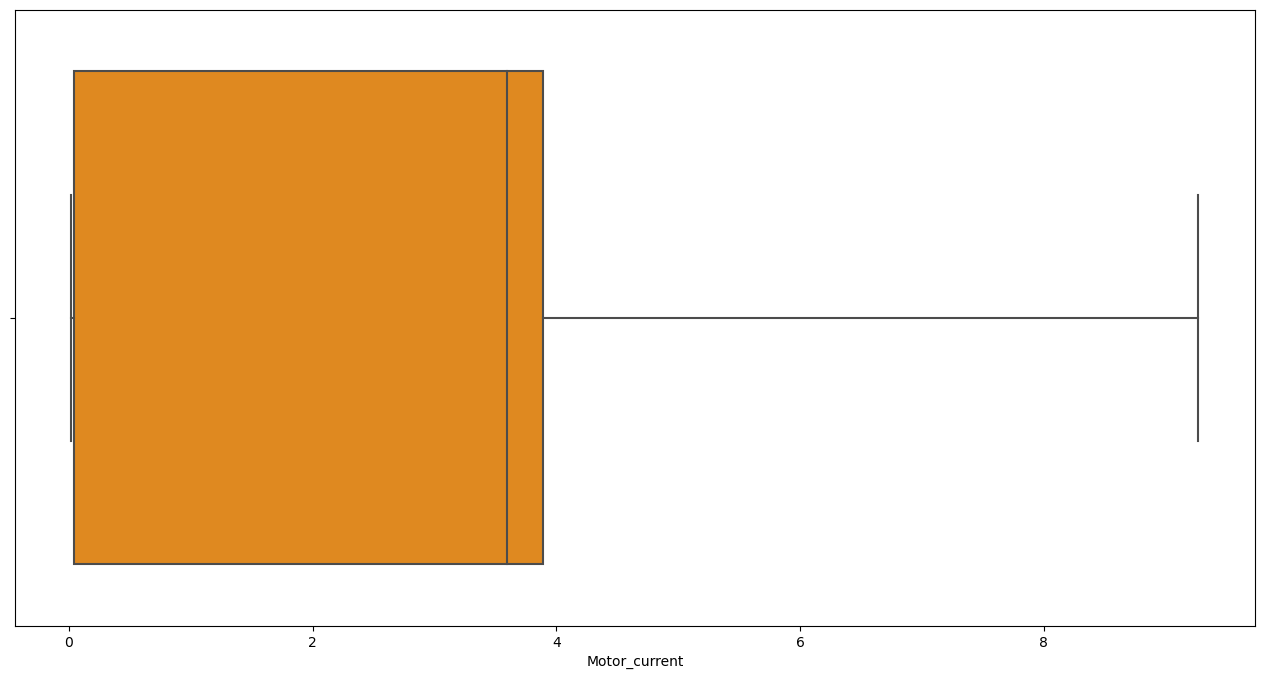

In [22]:
for col in sayisal_degiskenler:
    outlier_th(df,col)

In [59]:
def num_of_outliers(dataframe,col,q1=0.01,q3=0.99):
    quar1 = dataframe[col].quantile(q1)
    quar3 = dataframe[col].quantile(q3)
    
    iqr = quar3 - quar1
    
    low_Limit = quar1 - 1.5 * iqr
    up_Limit = quar3 + 1.5 * iqr
    
    outliers = dataframe[(dataframe[col] < low_Limit) | (dataframe[col] > up_Limit)]
    
    return len(outliers)

In [60]:
def print_outliers_num(dataframe,sayisal_degiskenler):
    sayac = 0
    for col in sayisal_degiskenler:
        out_len = num_of_outliers(dataframe,col)
        print(f"{col} outliers sayisi : {out_len} \n")
        sayac += out_len
        
    print(f"Toplam outliers sayısı {sayac} \n")
    print(f"Tum veriye oranı : {sayac / len(dataframe) * 100}")

In [25]:
print_outliers_num(df,sayisal_degiskenler)

TP2 outliers sayisi : 0 

TP3 outliers sayisi : 417 

H1 outliers sayisi : 0 

DV_pressure outliers sayisi : 98 

Reservoirs outliers sayisi : 423 

Oil_temperature outliers sayisi : 0 

Motor_current outliers sayisi : 0 

Toplam outliers sayısı 938 

Tum veriye oranı : 0.15373243672467962


In [26]:
len(df[df["Air_Leak_Failure"] == 1])

29954

In [49]:
clf = LocalOutlierFactor(n_neighbors=20)
clf.fit_predict(df[sayisal_degiskenler])
df_scores = clf.negative_outlier_factor_
df_scores

array([-1.        , -1.        , -1.        , ..., -1.00066952,
       -1.03276165, -9.15793122])

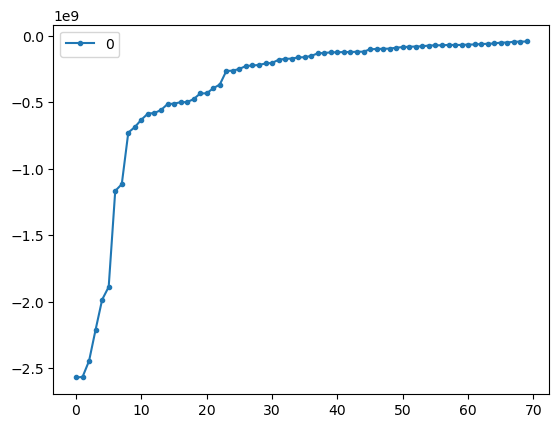

In [50]:
scores = pd.DataFrame(np.sort(df_scores))
scores[0:70].plot(style='.-')
plt.show()

In [51]:
np.sort(df_scores)[0:35]

array([-2.56790284e+09, -2.56380571e+09, -2.44270535e+09, -2.20768796e+09,
       -1.98253620e+09, -1.88681519e+09, -1.16521298e+09, -1.11458578e+09,
       -7.26489015e+08, -6.85073950e+08, -6.29493910e+08, -5.83899405e+08,
       -5.79397704e+08, -5.57009865e+08, -5.12561349e+08, -5.08729859e+08,
       -4.98257705e+08, -4.97339231e+08, -4.74978940e+08, -4.32309443e+08,
       -4.31116168e+08, -3.93078437e+08, -3.65624624e+08, -2.63350331e+08,
       -2.60767112e+08, -2.47737692e+08, -2.25820559e+08, -2.21995594e+08,
       -2.17991942e+08, -2.06743453e+08, -2.02971422e+08, -1.78959936e+08,
       -1.72107531e+08, -1.70280298e+08, -1.61054530e+08])

In [52]:
np.sort(df_scores)[18]

-474978939.89963543

In [53]:
th = np.sort(df_scores)[18]
df[df_scores < th].shape

(18, 17)

In [54]:
df.drop(list(df[df_scores < th].index),axis=0,inplace=True)

In [55]:
def remove_outlier(dataframe,col_name):
    lowLimit,upLimit = outlier_th(dataframe,col_name,q1=0.01,q3=0.99,plot=False)
    
    new_df = dataframe.loc[~((dataframe[col_name] < lowLimit) | (dataframe[col_name] > upLimit))]
    
    return new_df

In [56]:
def replace_with_th(dataframe,outliers_list):
    for col in outliers_list:
        low_limit,up_limit = outlier_th(dataframe,col,plot=False)
        
        dataframe.loc[dataframe[col] < low_limit,col] = low_limit
        dataframe.loc[dataframe[col] > up_limit,col] = up_limit

In [57]:
def outliers_listele(dataframe,sayisal_degiskenler):
    outliers_list = [col for col in sayisal_degiskenler if num_of_outliers(dataframe,col) > 0]
    
    return outliers_list

In [61]:
out_list = outliers_listele(df,sayisal_degiskenler)
out_list

['TP3', 'DV_pressure', 'Reservoirs']

In [62]:
for col in sayisal_degiskenler:
    df = remove_outlier(df,col)

NameError: name 'outlier_th' is not defined

In [ ]:
print_outliers_num(df,sayisal_degiskenler)

In [ ]:
len(df[df["Air_Leak_Failure"] == 1])

In [43]:
def Corr_analys(dataframe,figsize=(12,12),save=True):
    corr = dataframe.corr()
    
    plt.figure(figsize=figsize)
    heatmap = sns.heatmap(data = corr,vmin = -1,vmax = 1,annot = True,cmap = sns.color_palette("crest", as_cmap=True))
    plt.show()
    
    if save:
        heatmap.get_figure().savefig("korelasyon_heatmap.png")

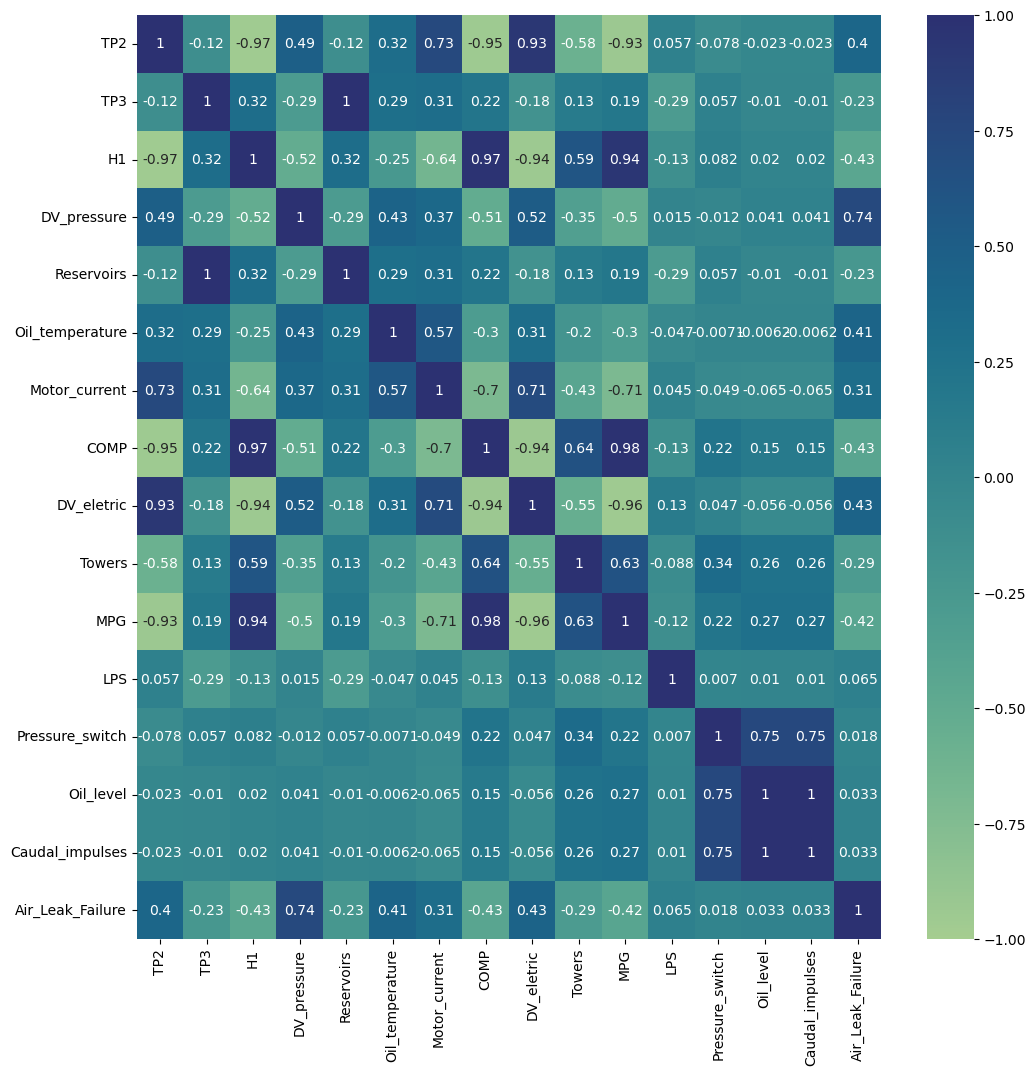

In [44]:
Corr_analys(df,save=False)

In [45]:
df[sayisal_degiskenler].describe().T

,count,mean,std,min,25%,50%,75%,max
TP2,609601.000,1.791,3.562,-0.032,-0.014,-0.012,-0.010,10.676
TP3,609601.000,8.944,0.651,3.748,8.440,8.900,9.474,10.288
H1,609601.000,7.096,3.715,-0.036,8.158,8.706,9.346,10.288
DV_pressure,609601.000,0.129,0.535,-0.030,-0.022,-0.020,-0.018,5.592
Reservoirs,609601.000,8.945,0.650,3.744,8.442,8.900,9.474,10.290
Oil_temperature,609601.000,64.074,6.321,27.750,59.875,64.600,68.250,89.050
Motor_current,609601.000,2.344,2.371,0.020,0.042,3.588,3.890,9.270


In [90]:
df.drop(["TP3","COMP","DV_eletric","Oil_level"],axis=1,inplace=True)

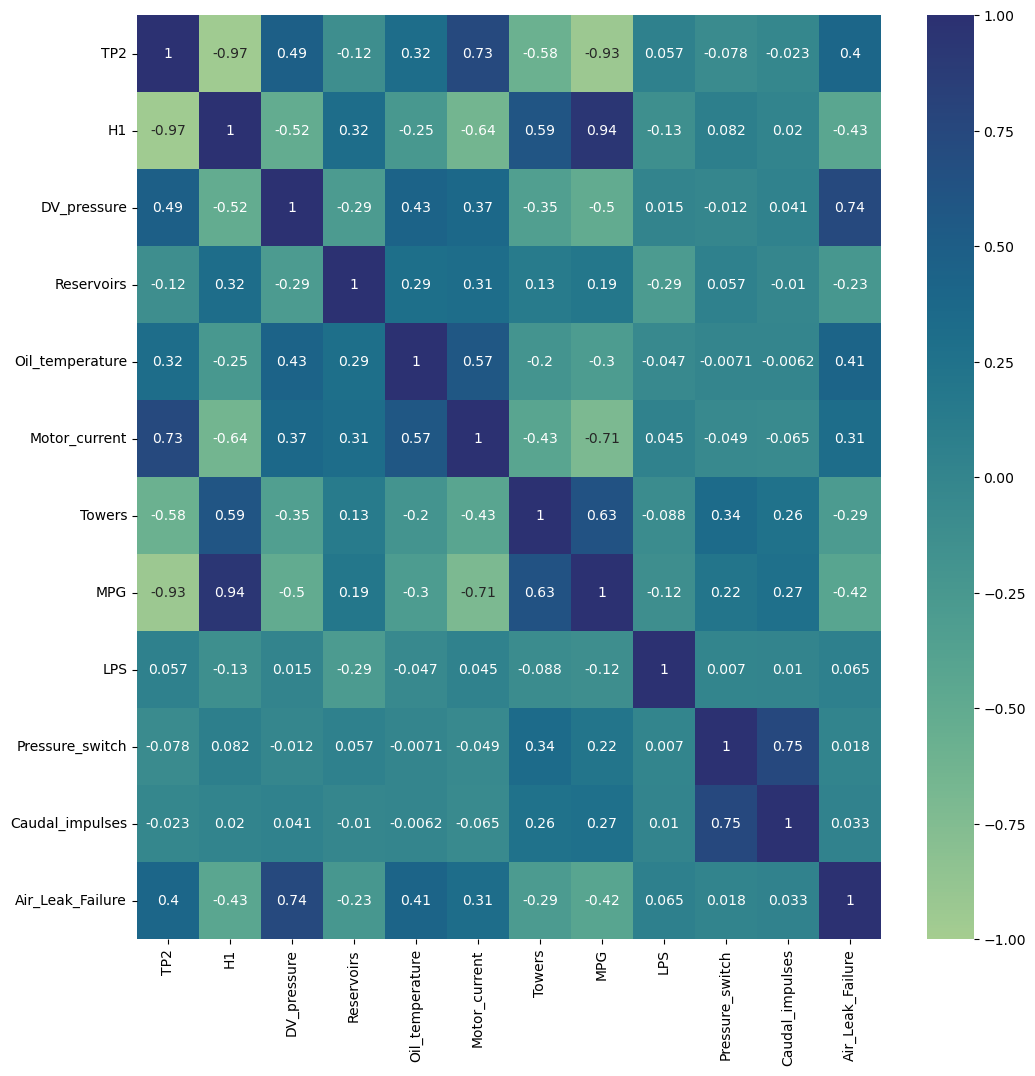

In [47]:
Corr_analys(df,save=False)

In [91]:
sayisal_degiskenler = [col for col in sayisal_degiskenler if col not in ['TP3']]

NameError: name 'sayisal_degiskenler' is not defined

In [24]:
sayisal_degiskenler

['TP2', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']

In [50]:
df[sayisal_degiskenler].describe().T

,count,mean,std,min,25%,50%,75%,max
TP2,609601.000,1.791,3.562,-0.032,-0.014,-0.012,-0.010,10.676
H1,609601.000,7.096,3.715,-0.036,8.158,8.706,9.346,10.288
DV_pressure,609601.000,0.129,0.535,-0.030,-0.022,-0.020,-0.018,5.592
Reservoirs,609601.000,8.945,0.650,3.744,8.442,8.900,9.474,10.290
Oil_temperature,609601.000,64.074,6.321,27.750,59.875,64.600,68.250,89.050
Motor_current,609601.000,2.344,2.371,0.020,0.042,3.588,3.890,9.270


In [92]:
kategorik_degiskenler,sayisal_degiskenler,kat_ama_car = degisken_turlerini_ayır(df)
sayisal_degiskenler = [col for col in sayisal_degiskenler if col != "timestamp"]
sayisal_degiskenler

['TP2', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']

In [93]:
kategorik_degiskenler

['Towers',
 'MPG',
 'LPS',
 'Pressure_switch',
 'Caudal_impulses',
 'Air_Leak_Failure']

In [71]:
start = '2020-04-18 00:00:00'
end = '2020-04-19 23:59:00'
df[(df['timestamp'] >= start) & (df['timestamp'] <= end)]

,timestamp,TP2,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,Towers,MPG,LPS,Pressure_switch,Caudal_impulses,Air_Leak_Failure
562564,2020-04-18 00:00:01,-0.018,8.238,-0.024,8.248,49.450,0.040,1.000,1.000,0.000,1.000,1.000,1
562565,2020-04-18 00:00:13,-0.018,8.238,-0.024,8.248,49.450,0.040,1.000,1.000,0.000,1.000,1.000,1
562566,2020-04-18 00:00:24,-0.018,8.238,-0.024,8.248,49.450,0.040,1.000,1.000,0.000,1.000,1.000,1
562567,2020-04-18 00:00:36,-0.018,8.238,-0.024,8.248,49.450,0.040,0.000,0.000,0.000,0.000,0.000,1
562568,2020-04-18 00:00:49,-0.018,8.238,-0.024,8.248,49.450,0.040,1.000,1.000,0.000,1.000,1.000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
579771,2020-04-19 23:58:14,-0.016,8.316,-0.024,8.328,55.100,0.040,1.000,1.000,0.000,1.000,1.000,0
579772,2020-04-19 23:58:23,-0.016,8.304,-0.024,8.318,55.125,0.040,1.000,1.000,0.000,1.000,1.000,0
579773,2020-04-19 23:58:33,-0.014,8.294,-0.024,8.304,55.050,0.042,1.000,1.000,0.000,1.000,1.000,0
579774,2020-04-19 23:58:43,-0.016,8.280,-0.024,8.292,55.000,0.042,1.000,1.000,0.000,1.000,1.000,0


In [27]:
df["remaining_life"] = np.nan

In [28]:
len(df)

48073

In [74]:
df_first = df[(df["timestamp"] >= "2020-02-01 00:00:00") & ((df["timestamp"] < "2020-04-18 00:00:00"))]

In [75]:
len(df_first)

0

In [29]:
liste = list(df[df["Air_Leak_Failure"] == 1].index)

In [30]:
for index in liste:
    df.at[index,"remaining_life"] = 0 

In [31]:
df["remaining_life"].value_counts()

0.000    363
Name: remaining_life, dtype: int64

In [18]:
df.head()

,timestamp,TP2,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,Towers,MPG,LPS,Pressure_switch,Caudal_impulses,Air_Leak_Failure,remaining_life
842737,2020-05-30 05:00:07,5.830,-0.008,1.236,8.390,76.200,5.107,0.000,0.000,0.000,1.000,1.000,1,0.000
842738,2020-05-30 05:00:17,7.710,-0.010,1.784,8.370,76.425,5.382,0.000,0.000,0.000,1.000,1.000,1,0.000
842739,2020-05-30 05:00:27,8.500,-0.006,2.034,8.352,76.500,5.537,0.000,0.000,0.000,1.000,1.000,1,0.000
842740,2020-05-30 05:00:36,8.546,-0.008,2.044,8.358,76.475,5.615,0.000,0.000,0.000,1.000,1.000,1,0.000
842741,2020-05-30 05:00:46,8.542,-0.008,2.044,8.366,76.300,5.685,0.000,0.000,0.000,1.000,1.000,1,0.000


In [32]:
down_periods = [
    ('2020-02-01 00:00:00', '2020-04-18 00:00:00'),
    ('2020-04-18 23:59:01', '2020-05-29 23:30:00'),
    ('2020-05-30 06:00:01', '2020-06-05 10:00:00'),
    ('2020-06-07 14:30:01', '2020-07-15 14:30:00'),
    ('2020-07-15 19:00:01','2020-09-01 03:59:50')
]


In [33]:
second_period = list(df[(df["timestamp"] >= '2020-04-18 23:59:01') & ((df["timestamp"] < '2020-05-29 23:30:00'))].index)
third_period = list(df[(df["timestamp"] >= '2020-05-30 06:00:01') & ((df["timestamp"] < '2020-06-05 10:00:00'))].index)
fourth_period = list(df[(df["timestamp"] >= '2020-06-07 14:30:01') & ((df["timestamp"] < '2020-07-15 14:30:00'))].index)

In [34]:
def fill_ratio(dataframe,liste):
    boyut = len(liste)
    kalan_omur_degerleri = [(boyut - i - 1) / (boyut - 1) * 100 for i in range(boyut)]
    sayac = 0
    for index in liste:
        dataframe.at[index,"remaining_life"] = kalan_omur_degerleri[sayac]
        sayac += 1

In [68]:
boyut = len(first_period)
kalan_omur_degerleri = [(boyut - i - 1) / (boyut - 1) * 100 for i in range(boyut)]
sayac = 0
for index in first_period:
    df.at[index,"remaining_life"] = kalan_omur_degerleri[sayac]
    sayac += 1

NameError: name 'first_period' is not defined

In [74]:
df.tail(500)

,timestamp,TP2,DV_pressure,Reservoirs,Oil_temperature,Motor_current,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,Air_Leak_Failure,remaining_life
1516447,2020-09-01 00:42:20,-0.014,-0.022,9.864,62.050,3.950,1.000,1.000,0.000,1.000,1.000,1.000,0,NaN
1516448,2020-09-01 02:37:24,-0.014,-0.022,9.948,59.500,3.768,1.000,1.000,0.000,1.000,1.000,1.000,0,NaN
1516449,2020-09-01 02:37:34,-0.014,-0.022,9.922,59.500,3.765,1.000,1.000,0.000,1.000,1.000,1.000,0,NaN
1516450,2020-09-01 02:37:44,-0.014,-0.022,9.900,59.300,3.803,1.000,1.000,0.000,1.000,1.000,1.000,0,NaN
1516451,2020-09-01 02:37:54,-0.014,-0.020,9.878,59.375,3.772,1.000,1.000,0.000,1.000,1.000,1.000,0,NaN
1516452,2020-09-01 02:38:04,-0.012,-0.022,9.858,59.475,3.782,1.000,1.000,0.000,1.000,1.000,1.000,0,NaN
1516453,2020-09-01 02:38:14,-0.014,-0.022,9.836,59.675,3.848,1.000,1.000,0.000,1.000,1.000,1.000,0,NaN
1516454,2020-09-01 02:38:24,-0.014,-0.022,9.818,59.575,3.810,1.000,1.000,0.000,1.000,1.000,1.000,0,NaN
1516455,2020-09-01 02:38:34,-0.014,-0.022,9.798,59.475,3.882,1.000,1.000,0.000,1.000,1.000,1.000,0,NaN
1516456,2020-09-01 02:38:43,-0.012,-0.022,9.776,59.000,3.788,1.000,1.000,0.000,1.000,1.000,1.000,0,NaN


In [35]:
listeler = [second_period,third_period,fourth_period]

In [36]:
for liste in listeler:
    fill_ratio(df,liste)

In [37]:
df.isnull().sum()

timestamp           0
TP2                 0
H1                  0
DV_pressure         0
Reservoirs          0
Oil_temperature     0
Motor_current       0
Towers              0
MPG                 0
LPS                 0
Pressure_switch     0
Caudal_impulses     0
Air_Leak_Failure    0
remaining_life      0
dtype: int64

In [28]:
kontrol = df[df["Air_Leak_Failure"] == 1]
kontrol["remaining_life"].value_counts()

0.000    363
Name: remaining_life, dtype: int64

In [62]:
df.head(500)

,timestamp,TP2,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,Towers,MPG,LPS,Pressure_switch,Caudal_impulses,Air_Leak_Failure,remaining_life
843100,2020-05-30 06:00:04,0.000,9.644,-0.010,9.666,71.900,3.818,1.000,1.000,0.000,1.000,1.000,0,100.000
843101,2020-05-30 06:00:14,0.000,9.624,-0.010,9.648,71.825,3.888,1.000,1.000,0.000,1.000,1.000,0,98.990
843102,2020-05-30 06:00:24,0.000,9.602,-0.012,9.624,71.625,3.865,1.000,1.000,0.000,1.000,1.000,0,97.980
843103,2020-05-30 06:00:34,0.002,9.584,-0.010,9.606,71.425,3.765,1.000,1.000,0.000,1.000,1.000,0,96.970
843104,2020-05-30 06:00:44,0.000,9.564,-0.010,9.586,71.275,3.728,1.000,1.000,0.000,1.000,1.000,0,95.960
843105,2020-05-30 06:00:54,0.000,9.542,-0.012,9.562,71.125,3.725,1.000,1.000,0.000,1.000,1.000,0,94.949
843106,2020-05-30 06:01:04,0.002,9.522,-0.010,9.544,70.900,3.790,1.000,1.000,0.000,1.000,1.000,0,93.939
843107,2020-05-30 06:01:14,0.000,9.504,-0.010,9.526,70.825,3.868,1.000,1.000,0.000,1.000,1.000,0,92.929
843108,2020-05-30 06:01:24,0.002,9.486,-0.010,9.506,70.700,3.893,1.000,1.000,0.000,1.000,1.000,0,91.919
843109,2020-05-30 06:01:33,0.000,9.464,-0.012,9.486,70.700,3.840,1.000,1.000,0.000,1.000,1.000,0,90.909


In [65]:
df[sayisal_degiskenler].describe().T

,count,mean,std,min,25%,50%,75%,max
TP2,609601.000,1.791,3.562,-0.032,-0.014,-0.012,-0.010,10.676
H1,609601.000,7.096,3.715,-0.036,8.158,8.706,9.346,10.288
DV_pressure,609601.000,0.129,0.535,-0.030,-0.022,-0.020,-0.018,5.592
Reservoirs,609601.000,8.945,0.650,3.744,8.442,8.900,9.474,10.290
Oil_temperature,609601.000,64.074,6.321,27.750,59.875,64.600,68.250,89.050
Motor_current,609601.000,2.344,2.371,0.020,0.042,3.588,3.890,9.270


In [38]:
bins = [20, 55, 70, 90]
labels = ['Low', 'Medium', 'High']

df['Oil_temperature_category'] = pd.cut(df['Oil_temperature'], bins=bins, labels=labels)


In [39]:
df.Oil_temperature_category.value_counts()

Medium    42078
High       5765
Low         230
Name: Oil_temperature_category, dtype: int64

In [40]:
bins = [0,2,5,7,9.5]
labels = ['turns_off', 'offloaded', 'under_load','working']

df['Motor_current_category'] = pd.cut(df['Motor_current'], bins=bins, labels=labels)

In [41]:
df.Motor_current_category.value_counts()

turns_off     27270
offloaded     14789
under_load     6008
working           6
Name: Motor_current_category, dtype: int64

In [42]:
df["Oil_Res_Ratio"] = df["Oil_temperature"] / df["Reservoirs"]

In [43]:
df["H1_times_Res"] = df["H1"] * df["Reservoirs"]

In [44]:
df["Motor_times_Oil"] = df["Motor_current"] * df["Oil_temperature"] 

In [36]:
len(df.columns)

19

In [53]:
list(df.columns)

['timestamp',
 'TP2',
 'H1',
 'DV_pressure',
 'Reservoirs',
 'Oil_temperature',
 'Motor_current',
 'remaining_life',
 'Oil_Res_Ratio',
 'H1_times_Res',
 'Motor_times_Oil',
 'Towers_1.0',
 'MPG_1.0',
 'LPS_1.0',
 'Pressure_switch_1.0',
 'Air_Leak_Failure_1',
 'Oil_temperature_category_Medium',
 'Oil_temperature_category_High',
 'Motor_current_category_offloaded',
 'Motor_current_category_under_load',
 'Motor_current_category_working']

In [71]:
dtc = joblib.load("DecisionTC.joblib")

In [73]:
len(list(dtc.feature_names_in_))

19

In [73]:
df.remaining_life.describe()

count   609601.000
mean        47.545
std         30.152
min          0.000
25%         21.127
50%         47.418
75%         73.709
max        100.000
Name: remaining_life, dtype: float64

In [74]:
df.head()

,timestamp,TP2,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,Towers,MPG,LPS,Pressure_switch,Caudal_impulses,Air_Leak_Failure,remaining_life,Oil_temperature_category,Motor_current_category,Oil_Res_Ratio,H1_times_Res,Motor_times_Oil
562564,2020-04-18 00:00:01,-0.018,8.238,-0.024,8.248,49.450,0.040,1.000,1.000,0.000,1.000,1.000,1,0.000,Low,turns_off,5.995,67.947,1.978
562565,2020-04-18 00:00:13,-0.018,8.238,-0.024,8.248,49.450,0.040,1.000,1.000,0.000,1.000,1.000,1,0.000,Low,turns_off,5.995,67.947,1.978
562566,2020-04-18 00:00:24,-0.018,8.238,-0.024,8.248,49.450,0.040,1.000,1.000,0.000,1.000,1.000,1,0.000,Low,turns_off,5.995,67.947,1.978
562567,2020-04-18 00:00:36,-0.018,8.238,-0.024,8.248,49.450,0.040,0.000,0.000,0.000,0.000,0.000,1,0.000,Low,turns_off,5.995,67.947,1.978
562568,2020-04-18 00:00:49,-0.018,8.238,-0.024,8.248,49.450,0.040,1.000,1.000,0.000,1.000,1.000,1,0.000,Low,turns_off,5.995,67.947,1.978


In [45]:
kategorik_degiskenler,sayisal_degiskenler,kat_ama_car = degisken_turlerini_ayır(df)

In [46]:

kategorik_degiskenler

['Towers',
 'MPG',
 'LPS',
 'Pressure_switch',
 'Caudal_impulses',
 'Air_Leak_Failure',
 'Oil_temperature_category',
 'Motor_current_category']

In [47]:
sayisal_degiskenler

['TP2',
 'H1',
 'DV_pressure',
 'Reservoirs',
 'Oil_temperature',
 'Motor_current',
 'remaining_life',
 'Oil_Res_Ratio',
 'H1_times_Res',
 'Motor_times_Oil']

In [48]:
kat_ama_car

['timestamp']

In [49]:
len(df.columns)

19

In [77]:
df.head()

,timestamp,TP2,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,Towers,MPG,LPS,Pressure_switch,Caudal_impulses,Air_Leak_Failure,remaining_life,Oil_temperature_category,Motor_current_category,Oil_Res_Ratio,H1_times_Res,Motor_times_Oil
562564,2020-04-18 00:00:01,-0.018,8.238,-0.024,8.248,49.450,0.040,1.000,1.000,0.000,1.000,1.000,1,0.000,Low,turns_off,5.995,67.947,1.978
562565,2020-04-18 00:00:13,-0.018,8.238,-0.024,8.248,49.450,0.040,1.000,1.000,0.000,1.000,1.000,1,0.000,Low,turns_off,5.995,67.947,1.978
562566,2020-04-18 00:00:24,-0.018,8.238,-0.024,8.248,49.450,0.040,1.000,1.000,0.000,1.000,1.000,1,0.000,Low,turns_off,5.995,67.947,1.978
562567,2020-04-18 00:00:36,-0.018,8.238,-0.024,8.248,49.450,0.040,0.000,0.000,0.000,0.000,0.000,1,0.000,Low,turns_off,5.995,67.947,1.978
562568,2020-04-18 00:00:49,-0.018,8.238,-0.024,8.248,49.450,0.040,1.000,1.000,0.000,1.000,1.000,1,0.000,Low,turns_off,5.995,67.947,1.978


In [40]:
kategorik_degiskenler

['Towers',
 'MPG',
 'LPS',
 'Pressure_switch',
 'Caudal_impulses',
 'Air_Leak_Failure']

In [50]:
ss = StandardScaler()
df[sayisal_degiskenler] = ss.fit_transform(df[sayisal_degiskenler])

In [51]:
df = pd.get_dummies(data=df,columns=kategorik_degiskenler,drop_first=True)
# df = pd.get_dummies(data=df,columns=kategorik_degiskenler)

In [52]:
df.head()

,timestamp,TP2,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,remaining_life,Oil_Res_Ratio,H1_times_Res,Motor_times_Oil,Towers_1.0,MPG_1.0,LPS_1.0,Pressure_switch_1.0,Air_Leak_Failure_1,Oil_temperature_category_Medium,Oil_temperature_category_High,Motor_current_category_offloaded,Motor_current_category_under_load,Motor_current_category_working
842737,2020-05-30 05:00:07,1.518,-2.479,4.011,-0.998,2.544,1.414,-1.706,5.531,-2.380,1.697,0,0,0,1,1,0,1,0,1,0
842738,2020-05-30 05:00:17,2.129,-2.480,5.826,-1.031,2.593,1.537,-1.706,5.671,-2.381,1.843,0,0,0,1,1,0,1,0,1,0
842739,2020-05-30 05:00:27,2.386,-2.479,6.655,-1.060,2.609,1.606,-1.706,5.754,-2.380,1.923,0,0,0,1,1,0,1,0,1,0
842740,2020-05-30 05:00:36,2.401,-2.479,6.688,-1.050,2.604,1.640,-1.706,5.726,-2.380,1.961,0,0,0,1,1,0,1,0,1,0
842741,2020-05-30 05:00:46,2.399,-2.479,6.688,-1.037,2.566,1.671,-1.706,5.640,-2.380,1.990,0,0,0,1,1,0,1,0,1,0


In [88]:
kontrol = df[df["Air_Leak_Failure"] == 0]
kontrol[sayisal_degiskenler].describe().T

,count,mean,std,min,25%,50%,75%,max
TP2,579664.000,-0.092,0.936,-0.512,-0.507,-0.506,-0.506,2.494
H1,579664.000,0.098,0.924,-1.920,0.304,0.449,0.614,0.859
DV_pressure,579664.000,-0.167,0.659,-0.297,-0.282,-0.278,-0.275,10.214
Reservoirs,579664.000,0.052,0.984,-8.002,-0.702,0.005,0.858,2.070
Oil_temperature,579664.000,-0.094,0.927,-5.747,-0.712,0.016,0.550,2.927
Motor_current,579664.000,-0.069,0.976,-0.980,-0.971,-0.970,0.627,2.921
remaining_life,579664.000,0.081,0.957,-1.577,-0.748,0.081,0.911,1.740
Oil_Res_Ratio,579664.000,-0.127,0.828,-3.473,-0.707,-0.070,0.320,15.924
H1_times_Res,579664.000,0.095,0.930,-1.866,0.102,0.367,0.689,1.203
Motor_times_Oil,579664.000,-0.083,0.954,-0.974,-0.964,-0.962,0.653,2.575


In [89]:
X = df.drop(["timestamp","Air_Leak_Failure","remaining_life"],axis=1)
y = df["Air_Leak_Failure"]

In [90]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=52)

In [91]:
DTC = DecisionTreeClassifier()
DTC.fit(X_train,y_train)

DecisionTreeClassifier()

In [92]:
y_pred = DTC.predict(X_test)
accuracy_score(y_pred,y_test)

0.9979396460653145

In [93]:
confusion_matrix(y_pred,y_test)

array([[144820,    162],
       [   152,   7267]], dtype=int64)

In [96]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    144982
           1       0.98      0.98      0.98      7419

    accuracy                           1.00    152401
   macro avg       0.99      0.99      0.99    152401
weighted avg       1.00      1.00      1.00    152401



In [97]:
joblib.dump(DTC,"DecisionTC.joblib")

['DecisionTC.joblib']

In [2]:
DTC = joblib.load("DecisionTC.joblib")

In [3]:
DTC.feature_names_in_

array(['TP2', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature',
       'Motor_current', 'Oil_Res_Ratio', 'H1_times_Res',
       'Motor_times_Oil', 'Towers_1.0', 'MPG_1.0', 'LPS_1.0',
       'Pressure_switch_1.0', 'Caudal_impulses_1.0',
       'Oil_temperature_category_Medium', 'Oil_temperature_category_High',
       'Motor_current_category_offloaded',
       'Motor_current_category_under_load',
       'Motor_current_category_working'], dtype=object)

In [109]:
sample = df[df["Air_Leak_Failure"] == 1].sample(1)
sample.drop(["Air_Leak_Failure","timestamp","remaining_life"],axis=1,inplace=True)

In [110]:
np.array(sample)

array([[ 1.81862573, -1.91224029,  3.13932142, -0.18239255,  1.46748688,
         1.32977822,  1.40937077, -1.85942651,  1.50781361,  1.        ,
         0.        ,  0.        ,  1.        ,  1.        ,  0.        ,
         1.        ,  0.        ,  1.        ,  0.        ]])

In [111]:
DTC.predict([[ 1.81862573, -1.91224029,  3.13932142, -0.18239255,  1.46748688,
         1.32977822,  1.40937077, -1.85942651,  1.50781361,  1.        ,
         0.        ,  0.        ,  1.        ,  1.        ,  0.        ,
         1.        ,  0.        ,  1.        ,  0.        ]])

array([1], dtype=int64)

In [368]:
# pca = PCA()
# pca_fit = pca.fit_transform(df)

In [369]:
# pca.explained_variance_ratio_
# np.cumsum(pca.explained_variance_ratio_)

array([0.445897  , 0.68167442, 0.81372769, 0.87381128, 0.91684347,
       0.94243805, 0.96079387, 0.97831724, 0.99079604, 0.99388063,
       0.99689249, 0.99859385, 0.99927437, 0.99982008, 0.99992245,
       0.9999918 , 0.99999876, 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        ])

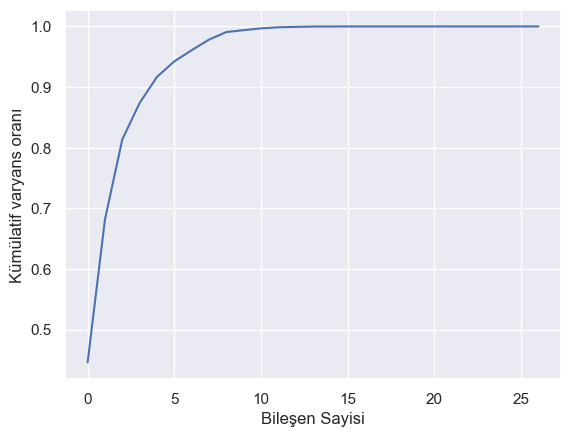

In [370]:
# pca = PCA().fit(X_train)
# plt.plot(np.cumsum(pca.explained_variance_ratio_))
# plt.xlabel("Bileşen Sayisi")
# plt.ylabel("Kümülatif varyans oranı")
# plt.show()

In [133]:
list(df.columns)

['timestamp',
 'TP2',
 'H1',
 'DV_pressure',
 'Reservoirs',
 'Oil_temperature',
 'Motor_current',
 'Towers',
 'MPG',
 'LPS',
 'Pressure_switch',
 'Caudal_impulses',
 'Air_Leak_Failure',
 'remaining_life',
 'Oil_temperature_category',
 'Motor_current_category',
 'Oil_Res_Ratio',
 'H1_times_Res',
 'Motor_times_Oil']

In [188]:
X = df.drop(["remaining_life","timestamp"],axis=1)
y = df["remaining_life"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=25)

In [189]:
DTR = DecisionTreeRegressor(random_state=35)
DTR.fit(X_train,y_train)
y_pred = DTR.predict(X_test)
mse = mean_squared_error(y_pred,y_test)
print(mse)

844.6288784742426


In [190]:
r2 = r2_score(y_pred,y_test)
r2

0.07937380360815938

In [191]:
y_pred = pd.DataFrame(y_pred)
y_pred.describe()

,0
count,152401.000
mean,47.421
std,30.290
min,0.000
25%,20.773
50%,47.224
75%,73.819
max,100.000


In [192]:
y_test.describe()

count   152401.000
mean        47.571
std         30.172
min          0.000
25%         21.195
50%         47.408
75%         73.757
max        100.000
Name: remaining_life, dtype: float64

In [289]:
samp = X_test[X_test["Air_Leak_Failure_1"] == 1]
samp2 = samp.iloc[0:10]

In [200]:
samp1 = samp.sample(1)
np.array(samp1)

array([[ 1.85283031, -1.91220325,  3.90959678, -1.17951505,  1.68502275,
         1.35717561,  2.44781356, -1.85924231,  1.58438599,  1.        ,
         0.        ,  0.        ,  1.        ,  1.        ,  1.        ,
         0.        ,  1.        ,  0.        ,  1.        ,  0.        ]])

In [211]:
pred = DTR.predict(samp)
pred = pd.DataFrame(pred)
pred.describe()

,0
count,7469.000
mean,0.000
std,0.000
min,0.000
25%,0.000
50%,0.000
75%,0.000
max,0.000


In [203]:
pred2 = DTR.predict(samp2)
pred2

array([ 0.        , 54.45854675, 88.41785697, 48.41492525,  0.        ,
       23.15981789, 30.49158169, 36.01936917,  1.68403306, 21.94434821])

In [272]:
samp2

,TP2,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,Oil_Res_Ratio,H1_times_Res,Motor_times_Oil,Towers_1.0,MPG_1.0,LPS_1.0,Pressure_switch_1.0,Caudal_impulses_1.0,Air_Leak_Failure_1,Oil_temperature_category_Medium,Oil_temperature_category_High,Motor_current_category_offloaded,Motor_current_category_under_load,Motor_current_category_working
1172578,1.424,-1.911,-0.260,-3.909,2.389,1.232,6.500,-1.858,1.592,1,0,1,1,1,1,0,1,0,1,0
900273,1.826,-1.911,3.887,-1.269,2.045,1.356,2.882,-1.858,1.661,0,0,0,1,1,1,0,1,0,1,0
1172049,1.766,-1.910,-0.260,-1.967,3.038,1.320,4.616,-1.857,1.833,0,0,0,1,1,1,0,1,0,1,0
1171718,1.899,-1.910,-0.256,-1.235,3.524,1.309,4.292,-1.857,1.922,1,0,0,1,1,1,0,1,0,1,0
565532,2.031,-1.912,3.532,-0.096,1.487,1.452,1.361,-1.859,1.643,0,0,0,1,1,1,0,1,0,1,0
902133,1.725,-1.913,3.569,-1.564,1.669,1.321,2.794,-1.860,1.542,0,0,0,1,1,1,0,1,0,1,0
906507,1.769,-1.912,3.360,-1.610,1.946,1.304,3.117,-1.859,1.582,0,0,0,1,1,1,0,1,0,1,0
899280,1.341,-1.912,2.807,-1.244,1.966,1.180,2.781,-1.859,1.447,0,0,0,1,1,1,0,1,0,1,0
566554,2.043,-1.912,3.577,-0.072,1.804,1.476,1.625,-1.859,1.742,1,0,0,1,1,1,0,1,0,1,0
569042,2.038,-1.911,3.562,-0.109,1.479,1.481,1.364,-1.858,1.672,1,0,0,1,1,1,0,1,0,1,0


In [212]:
#joblib.dump(DTR,"DecisionTR.joblib")

['DecisionTR.joblib']

In [213]:
DecisionTR = joblib.load("DecisionTR.joblib")

In [222]:
pred2 = DecisionTR.predict(samp2)
pred2

array([26.64053   , 14.03187594, 25.47845387, 29.58253804, 58.42295817,
       27.40597482, 26.96663862, 93.17467992, 14.29410038, 63.81909734])

In [286]:
samp2 = df[df["Air_Leak_Failure_1"] == 0]

In [287]:
samp2 = samp2.iloc[0:100]
samp2.drop(["timestamp","remaining_life"],axis=1,inplace=True)

In [288]:
pred_samp = DecisionTR.predict(samp2)
pred_samp

array([100.        ,  99.99962866,  99.99962866,  99.99888598,
        99.99851463,  99.99814329,  99.99777195,  99.99740061,
        99.99702927,  99.99665793,  99.99628659,  99.99591525,
        99.99814329,  99.99517256,  99.99480122,  99.99442988,
        99.99405854,  99.9936872 ,  99.99331586,  99.96100916,
        99.99257317,  99.99220183,  99.99183049,  99.99145915,
        99.99108781,  99.99071647,  99.99034512,  99.99962866,
        99.98960244,  99.9892311 ,  99.98885976,  99.99814329,
        99.98811708,  99.98774574,  99.98737439,  99.95581038,
        99.97252074,  99.98626037,  99.98588903,  99.98551769,
        99.95172562,  99.984775  ,  99.98440366,  99.98403232,
        99.98366098,  99.98328964,  99.9829183 ,  99.94244209,
        99.98217561,  99.98180427,  99.95432501,  99.98106159,
        99.98069025,  99.9936872 ,  99.97994757,  34.48362615,
        99.96695062,  99.97883354,  99.9784622 ,  99.95581038,
        99.97771952,  99.97734818,  99.97697684,  99.97

In [263]:
sample = df.loc[704964]
sample = pd.DataFrame(sample)
sample.drop(["timestamp","remaining_life"],inplace=True)
sample

,704964
TP2,-0.507
H1,0.273
DV_pressure,-0.286
Reservoirs,-1.269
Oil_temperature,-1.598
Motor_current,-0.972
Oil_Res_Ratio,-0.680
H1_times_Res,0.047
Motor_times_Oil,-0.966
Towers_1.0,1


In [262]:
df.loc[704964]

timestamp                            2020-05-09 13:29:32
TP2                                               -0.507
H1                                                 0.273
DV_pressure                                       -0.286
Reservoirs                                        -1.269
Oil_temperature                                   -1.598
Motor_current                                     -0.972
remaining_life                                    50.379
Oil_Res_Ratio                                     -0.680
H1_times_Res                                       0.047
Motor_times_Oil                                   -0.966
Towers_1.0                                             1
MPG_1.0                                                1
LPS_1.0                                                0
Pressure_switch_1.0                                    1
Caudal_impulses_1.0                                    1
Air_Leak_Failure_1                                     0
Oil_temperature_category_Medium

In [264]:
np.array(sample).T

array([[-0.5067643828162154, 0.2733827082030408, -0.2857865918702866,
        -1.268764135619133, -1.59775598733474, -0.9718593860881298,
        -0.6803546032178295, 0.0471514361320788, -0.966211772187148, 1,
        1, 0, 1, 1, 0, 0, 0, 0, 0, 0]], dtype=object)

In [265]:
pred = DecisionTR.predict([[-0.5067643828162154, 0.2733827082030408, -0.2857865918702866,
        -1.268764135619133, -1.59775598733474, -0.9718593860881298,
        -0.6803546032178295, 0.0471514361320788, -0.966211772187148, 1,
        1, 0, 1, 1, 0, 0, 0, 0, 0, 0]])

In [266]:
pred

array([63.81909734])

In [291]:
len(DecisionTR.feature_names_in_)

20

In [296]:
%time
pred = DecisionTR.predict([[-0.5067643828162154, 0.2733827082030408, -0.2857865918702866,
        -1.268764135619133, -1.59775598733474, -0.9718593860881298,
        -0.6803546032178295, 0.0471514361320788, -0.966211772187148, 1,
        1, 0, 1, 1, 0, 0, 0, 0, 0, 0]])

Wall time: 0 ns


In [156]:
# DTR.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 35,
 'splitter': 'best'}

In [185]:
# dtr_params = {"max_depth":range(1,11),
              "min_samples_split":range(2,10)}
# grid_search = GridSearchCV(DTR,dtr_params,cv=5,scoring='r2',n_jobs=1,verbose=True).fit(X,y)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


In [186]:
# grid_search.best_params_

{'max_depth': 3, 'min_samples_split': 2}

In [187]:
# grid_search.best_score_

-2.979292690019842

In [171]:
#DTR = DTR.set_params(**grid_search.best_params_,random_state = 17).fit(X,y)

In [173]:
#DTR.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 17,
 'splitter': 'best'}

In [175]:
# y_pred = DTR.predict(X_test)

In [476]:
# random_forest = RandomForestRegressor()
# random_forest.fit(X_train,y_train)

RandomForestRegressor()

In [477]:
#joblib.dump(random_forest,"RandomForestRegressorModel.joblib")

['RandomForestRegressorModel.joblib']

In [123]:
# random_forest = joblib.load("RandomForestRegressorModel.joblib")

In [478]:
# y_pred = random_forest.predict(X_test)

In [479]:
# mse = mean_squared_error(y_pred,y_test)
# print(mse)

587.2890605421035


In [480]:
# r2 = r2_score(y_pred,y_test)
# print(r2)

-0.3657852908327841


In [197]:
# deneme = X_test.sample(10)
# deneme

,TP2,DV_pressure,Reservoirs,Oil_temperature,Motor_current,Towers_1.0,MPG_1.0,LPS_1.0,Pressure_switch_1.0,Oil_level_1.0,Caudal_impulses_1.0,Air_Leak_Failure_1,Oil_temperature_category_Low,Oil_temperature_category_Medium,Oil_temperature_category_High,Motor_current_category_offloaded,Motor_current_category_under_load,Motor_current_category_working
1084849,-0.423,-0.200,-1.406,-0.125,-0.872,1,1,0,1,1,1,0,0,1,0,0,0,0
847568,-0.423,-0.200,-0.721,-0.202,-0.872,1,1,0,1,1,1,0,0,1,0,0,0,0
1358719,-0.423,-0.205,-0.222,-0.194,-0.870,1,1,0,1,0,1,0,0,1,0,0,0,0
1151424,-0.423,-0.189,0.639,0.813,0.740,1,1,0,1,1,1,0,0,1,0,1,0,0
1214416,-0.422,-0.179,0.857,1.041,0.710,1,1,0,1,1,1,0,0,1,0,1,0,0
1000018,-0.424,-0.205,-0.809,-0.129,-0.871,1,1,0,1,1,1,0,0,1,0,0,0,0
1425805,-0.423,-0.200,-0.721,-0.260,-0.871,1,1,0,1,0,1,0,0,1,0,0,0,0
903357,2.102,5.522,-1.654,1.905,1.511,1,0,0,1,1,1,1,0,0,1,0,1,0
1250326,-0.423,-0.189,0.133,0.493,-0.871,1,1,0,1,1,1,0,0,1,0,0,0,0
1072678,-0.423,-0.205,1.056,0.801,0.750,1,1,0,1,1,1,0,0,1,0,1,0,0


In [198]:
# y_10 = random_forest.predict(deneme)

In [199]:
# y_10

array([49.6999343 , 78.0858023 , 45.8992911 , 36.42051793, 79.44294841,
       45.59693441, 37.61753747,  0.        , 46.94511245, 34.77027685])

In [155]:
# choose = random.sample(liste,10)
# choose

[842809,
 892221,
 899544,
 570021,
 895131,
 567270,
 902899,
 901971,
 904954,
 896070]

In [146]:
# np.array(X_test.loc[choose])

array([ 1.77679433,  4.21925697, -1.79779481,  2.1672565 ,  1.45153427,
        1.        ,  0.        ,  0.        ,  1.        ,  1.        ,
        1.        ,  1.        ,  0.        ,  0.        ,  1.        ,
        0.        ,  1.        ,  0.        ])

In [147]:
# pred = random_forest.predict([[ 2.14350959,  5.76178291, -1.35746012,  2.07079425,  1.56342821,
        0.        ,  0.        ,  0.        ,  1.        ,  1.        ,
        1.        ,  1.        ,  0.        ,  0.        ,  1.        ,
        0.        ,  1.        ,  0.        ]])

In [148]:
# pred

array([0.])

In [149]:
# choose = X_test.sample(1)
# choose

,TP2,DV_pressure,Reservoirs,Oil_temperature,Motor_current,Towers_1.0,MPG_1.0,LPS_1.0,Pressure_switch_1.0,Oil_level_1.0,Caudal_impulses_1.0,Air_Leak_Failure_1,Oil_temperature_category_Low,Oil_temperature_category_Medium,Oil_temperature_category_High,Motor_current_category_offloaded,Motor_current_category_under_load,Motor_current_category_working
427395,2.267,1.753,-0.738,2.592,1.609,1,0,0,1,1,1,0,0,0,1,0,1,0


In [151]:
# np.array(choose)

array([[ 2.26718369,  1.75335046, -0.73772981,  2.59169037,  1.60905486,
         1.        ,  0.        ,  0.        ,  1.        ,  1.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  1.        ,  0.        ]])

In [192]:
# pred = random_forest.predict([[-0.42349717, -0.21083481,  0.59958296, -1.39798805, -0.87216609,
        1.        ,  1.        ,  0.        ,  1.        ,  1.        ,
        1.        ,  0.        ,  0.        ,  1.        ,  0.        ,
#        0.        ,  0.        ,  0.      ]])

In [193]:
# pred

array([98.38164418])

In [193]:
def katsayilari_ciz(model, ozellikler, num=None, kaydet=False):
    if num is None:
        num = len(ozellikler.columns)
    
    # Random Forest için özellik önem derecelerini al
    ozellik_importances = model.feature_importances_
    ozellik_isimleri = ozellikler.columns
    
    # Özellik önem derecelerini bir DataFrame'e koy
    ozellik_imp = pd.DataFrame({"Deger": ozellik_importances, "Ozellik": ozellik_isimleri})
    
    # Özellikleri sıralayıp görselleştir
    plt.figure(figsize=(10, 10))
    sns.set(font_scale=1)
    sns.barplot(x="Deger", y="Ozellik", data=ozellik_imp.sort_values(by="Deger", ascending=False)[:num])
    plt.title("Özellik Önem Dereceleri")
    plt.tight_layout()
    plt.show(block=True)
    
    if kaydet:
        plt.savefig("ozellik_onem_dereceleri.png")


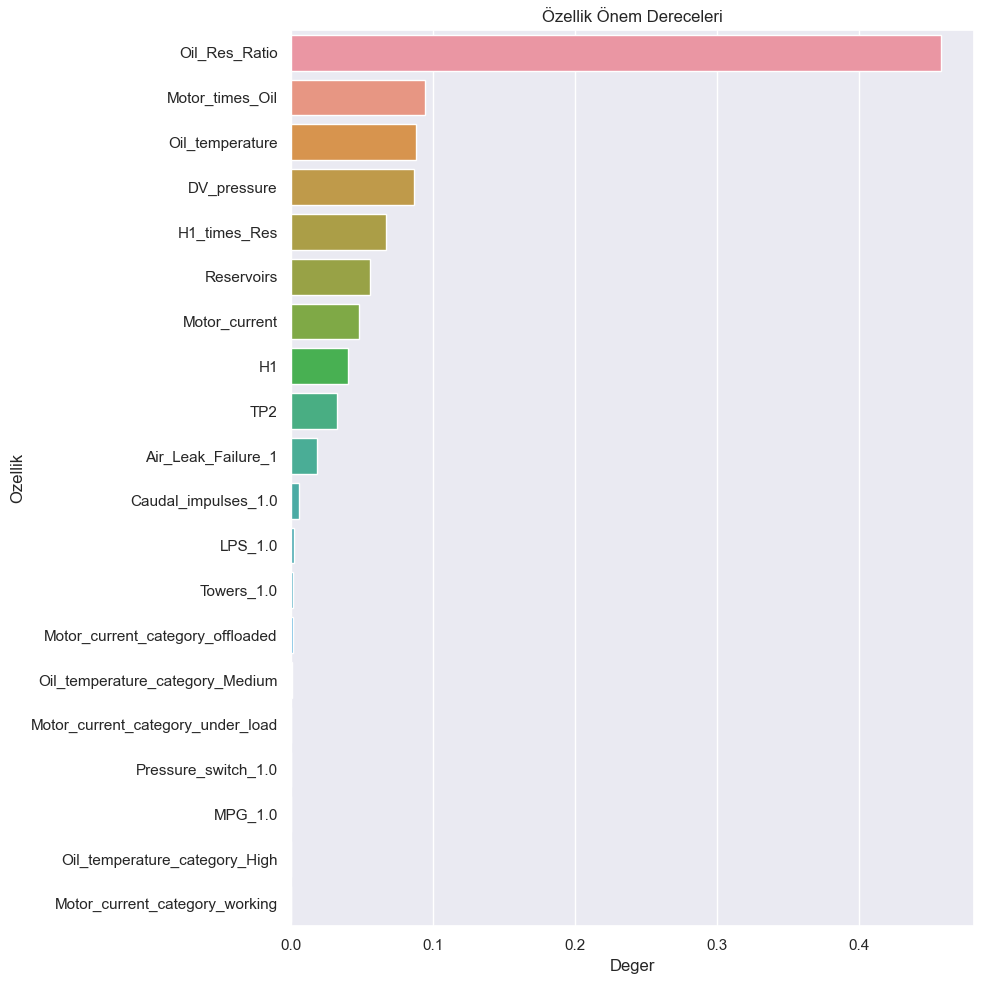

In [194]:
katsayilari_ciz(DTR,X)

In [191]:
# np.array(X_train.loc[0])

array([-0.42349717, -0.21083481,  0.59958296, -1.39798805, -0.87216609,
        1.        ,  1.        ,  0.        ,  1.        ,  1.        ,
        1.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  0.        ,  0.        ])

In [231]:
# df.head(5000)

,timestamp,TP2,DV_pressure,Reservoirs,Oil_temperature,Motor_current,remaining_life,Towers_1.0,MPG_1.0,LPS_1.0,Pressure_switch_1.0,Oil_level_1.0,Caudal_impulses_1.0,Air_Leak_Failure_1,Oil_temperature_category_Low,Oil_temperature_category_Medium,Oil_temperature_category_High,Motor_current_category_offloaded,Motor_current_category_under_load,Motor_current_category_working
0,2020-02-01 00:00:00,-0.423,-0.211,0.600,-1.398,-0.872,100.000,1,1,0,1,1,1,0,0,1,0,0,0,0
1,2020-02-01 00:00:10,-0.424,-0.205,0.583,-1.386,-0.872,100.000,1,1,0,1,1,1,0,0,1,0,0,0,0
2,2020-02-01 00:00:19,-0.423,-0.205,0.567,-1.398,-0.871,100.000,1,1,0,1,1,1,0,0,1,0,0,0,0
3,2020-02-01 00:00:29,-0.423,-0.205,0.551,-1.425,-0.872,99.999,1,1,0,1,1,1,0,0,1,0,0,0,0
4,2020-02-01 00:00:39,-0.423,-0.205,0.534,-1.417,-0.872,99.999,1,1,0,1,1,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2020-02-01 13:50:07,2.169,-0.179,-1.449,-0.781,1.614,99.111,0,0,0,1,1,1,0,0,1,0,0,1,0
4996,2020-02-01 13:50:17,2.255,-0.179,-1.155,-0.788,1.648,99.111,1,0,0,1,1,1,0,0,1,0,0,1,0
4997,2020-02-01 13:50:27,2.338,-0.179,-0.712,-0.788,1.633,99.111,1,0,0,1,1,1,0,0,1,0,0,1,0
4998,2020-02-01 13:50:37,2.414,-0.179,-0.288,-0.796,1.655,99.111,1,0,0,1,1,1,0,0,1,0,0,1,0


In [254]:
# samp = X_train.sample(1)
# samp

,TP2,DV_pressure,Reservoirs,Oil_temperature,Motor_current,Towers_1.0,MPG_1.0,LPS_1.0,Pressure_switch_1.0,Oil_level_1.0,Caudal_impulses_1.0,Air_Leak_Failure_1,Oil_temperature_category_Low,Oil_temperature_category_Medium,Oil_temperature_category_High,Motor_current_category_offloaded,Motor_current_category_under_load,Motor_current_category_working
25290,-0.424,-0.205,-1.041,-1.379,-0.873,1,1,0,1,1,1,0,0,1,0,0,0,0


In [253]:
# pred = random_forest.predict(samp)
# pred

array([44.63041006])

In [256]:
# random_forest.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 'auto',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [260]:
# y_pred.mean()

49.102547824216295

In [261]:
# y_train.mean()

49.00263958157148

In [264]:
# y_pred = pd.Series(y_pred)

In [269]:
# y_pred.describe()

count   378825.000
mean        49.103
std         20.743
min          0.000
25%         34.984
50%         48.311
75%         62.207
max         99.986
dtype: float64

In [270]:
# y_test = pd.Series(y_test)

In [271]:
# y_test.describe()

count   378825.000
mean        49.043
std         29.411
min          0.000
25%         23.543
50%         49.004
75%         74.521
max        100.000
Name: remaining_life, dtype: float64

In [379]:
# df

,TP2,DV_pressure,Reservoirs,Oil_temperature,Motor_current,remaining_life,Towers_0.0,Towers_1.0,MPG_0.0,MPG_1.0,LPS_0.0,LPS_1.0,Pressure_switch_0.0,Pressure_switch_1.0,Oil_level_0.0,Oil_level_1.0,Caudal_impulses_0.0,Caudal_impulses_1.0,Air_Leak_Failure_0,Air_Leak_Failure_1,Oil_temperature_category_Very Low,Oil_temperature_category_Low,Oil_temperature_category_Medium,Oil_temperature_category_High,Motor_current_category_turns_off,Motor_current_category_offloaded,Motor_current_category_under_load,Motor_current_category_working
0,-0.423,-0.211,0.600,-1.398,-0.872,100.000,0,1,0,1,1,0,0,1,0,1,0,1,1,0,0,0,1,0,1,0,0,0
1,-0.424,-0.205,0.583,-1.386,-0.872,100.000,0,1,0,1,1,0,0,1,0,1,0,1,1,0,0,0,1,0,1,0,0,0
2,-0.423,-0.205,0.567,-1.398,-0.871,100.000,0,1,0,1,1,0,0,1,0,1,0,1,1,0,0,0,1,0,1,0,0,0
3,-0.423,-0.205,0.551,-1.425,-0.872,99.999,0,1,0,1,1,0,0,1,0,1,0,1,1,0,0,0,1,0,1,0,0,0
4,-0.423,-0.205,0.534,-1.417,-0.872,99.999,0,1,0,1,1,0,0,1,0,1,0,1,1,0,0,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1516943,-0.424,-0.205,-0.118,-0.460,-0.871,0.001,0,1,0,1,1,0,0,1,0,1,0,1,1,0,0,0,1,0,1,0,0,0
1516944,-0.424,-0.200,-0.141,-0.472,-0.870,0.001,0,1,0,1,1,0,0,1,0,1,0,1,1,0,0,0,1,0,1,0,0,0
1516945,-0.424,-0.205,-0.160,-0.472,-0.871,0.001,0,1,0,1,1,0,0,1,0,1,0,1,1,0,0,0,1,0,1,0,0,0
1516946,-0.423,-0.205,-0.183,-0.480,-0.870,0.000,0,1,0,1,1,0,0,1,0,1,0,1,1,0,0,0,1,0,1,0,0,0
